In [1]:
import coderdata as cd
import os
import numpy as np
import pandas as pd
from umap import UMAP
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator  # Correct import for new RDKit
import pubchempy as pcp

/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
import coderdata_processing
import importlib
importlib.reload(coderdata_processing)
from coderdata_processing import filter_biomarkers, filter_feature, data_attribute_check, preprocess_experiment_with_footprint, cat_drug_response_features, unify_feature_across_dataset, get_total_mutation_types, summarize_datasets, summarize_df_matrices, binarize_across_dfs,  get_cell_id_across_dfs, cat_drug_response_features_across_datasets, dip_experiments_across_dfs, slice_data_across_dfs, visualize_responses_across_datasets, summarize_all_available_metrics, clean_experiments_across_dfs, visualize_sample_response_statistics, save_dfs_as_pt, count_features_by_variance_range, unify_cell_ids_across_dfs, cat_cell_features_across_datasets

In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [4]:
# datasets = ["beataml", "bladder", "ccle", "colorectal", "cptac", "ctrpv2", "fimm", "gcsi", "gdscv1", "gdscv2", "hcmi", "liver", "mpnst", "nci60", "novartis", "pancreatic", "prism", "sarcoma"]
# ignore dataset "cptac", "hcmi", "novartis", "sarcoma" due to response metric issues
datasets = ["beataml", "bladder", "ccle", "colorectal", "ctrpv2", "fimm", "gcsi", "gdscv1", "gdscv2", "liver", "mpnst", "nci60", "pancreatic", "prism"]
# avail_metrics = ["fit_auc", "fit_ic50", "fit_ec50", "fit_r2", "fit_ec50se", "fit_einf", "fit_hs", "aac", "auc", "dss"]


# bad datasets: ctrpv2, fimm, gdscv1, gdscv2, liver, mpnst, nci60, prism
# good datasets: ccle, gcsi, 
# datasets = ["prism"]
data_path = '../data/Cancer/coderdata/'
# for data_name in datasets:
#     cd.download(name=data_name, local_path=data_path)

loaded_datasets = {}
for data_name in datasets:
    print(f"Loading dataset: {data_name}")
    loaded_datasets[data_name] = cd.load(name=data_name, local_path=data_path)

Loading dataset: beataml


Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/beataml_transcriptomics.csv.gz ... DONE
Importing 'proteomics' from ../data/Cancer/coderdata/beataml_proteomics.csv.gz ... DONE
Importing 'mutations' from ../data/Cancer/coderdata/beataml_mutations.csv.gz ... DONE
'copy_number' not available for beataml
Importing 'samples' from ../data/Cancer/coderdata/beataml_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/beataml_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/beataml_drug_descriptors.tsv.gz ... DONE
'mirna' not available for beataml
Importing 'experiments' from ../data/Cancer/coderdata/beataml_experiments.tsv.gz ... DONE
'methylation' not available for beataml
'metabolomics' not available for beataml
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE
Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/bladder_transcriptomics.

Loading dataset: bladder


DONE
'proteomics' not available for bladder
Importing 'mutations' from ../data/Cancer/coderdata/bladder_mutations.csv.gz ... DONE
Importing 'copy_number' from ../data/Cancer/coderdata/bladder_copy_number.csv.gz ... DONE
Importing 'samples' from ../data/Cancer/coderdata/bladder_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/bladder_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/bladder_drug_descriptors.tsv.gz ... DONE
'mirna' not available for bladder
Importing 'experiments' from ../data/Cancer/coderdata/bladder_experiments.tsv.gz ... DONE
'methylation' not available for bladder
'metabolomics' not available for bladder
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE
Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/ccle_transcriptomics.csv.gz ... 

Loading dataset: ccle


...

DONE
Importing 'proteomics' from ../data/Cancer/coderdata/nci60_proteomics.csv.gz ... DONE
Importing 'mutations' from ../data/Cancer/coderdata/nci60_mutations.csv.gz ... DONE
Importing 'copy_number' from ../data/Cancer/coderdata/nci60_copy_number.csv.gz ... DONE
Importing 'samples' from ../data/Cancer/coderdata/nci60_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/nci60_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/nci60_drug_descriptors.tsv.gz ... DONE
'mirna' not available for nci60
Importing 'experiments' from ../data/Cancer/coderdata/nci60_experiments.tsv.gz ... DONE
'methylation' not available for nci60
'metabolomics' not available for nci60
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE
Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/pancreatic_transcriptomics.csv.gz ... 

Loading dataset: pancreatic


DONE
'proteomics' not available for pancreatic
Importing 'mutations' from ../data/Cancer/coderdata/pancreatic_mutations.csv.gz ... DONE
Importing 'copy_number' from ../data/Cancer/coderdata/pancreatic_copy_number.csv.gz ... DONE
Importing 'samples' from ../data/Cancer/coderdata/pancreatic_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/pancreatic_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/pancreatic_drug_descriptors.tsv.gz ... DONE
'mirna' not available for pancreatic
Importing 'experiments' from ../data/Cancer/coderdata/pancreatic_experiments.tsv.gz ... DONE
'methylation' not available for pancreatic
'metabolomics' not available for pancreatic
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE
Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/prism_transcriptomics.csv.gz ... 

Loading dataset: prism


DONE
Importing 'proteomics' from ../data/Cancer/coderdata/prism_proteomics.csv.gz ... DONE
Importing 'mutations' from ../data/Cancer/coderdata/prism_mutations.csv.gz ... DONE
Importing 'copy_number' from ../data/Cancer/coderdata/prism_copy_number.csv.gz ... DONE
Importing 'samples' from ../data/Cancer/coderdata/prism_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/prism_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/prism_drug_descriptors.tsv.gz ... DONE
'mirna' not available for prism
Importing 'experiments' from ../data/Cancer/coderdata/prism_experiments.tsv.gz ... DONE
'methylation' not available for prism
'metabolomics' not available for prism
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE


In [5]:
avail_metrics = summarize_all_available_metrics(loaded_datasets)
avail_metrics

Available metrics in dataset 'beataml': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'bladder': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'ccle': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'colorectal': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'ctrpv2': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'fimm': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'gcsi': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'gdscv1': ['fit_auc' 'fit_ic50' '

['aac',
 'fit_einf',
 'fit_auc',
 'fit_ec50se',
 'dss',
 'fit_ic50',
 'fit_r2',
 'fit_hs',
 'fit_ec50',
 'auc']

In [ ]:
# for metric in avail_metrics:
#     visualize_responses_across_datasets(loaded_datasets, metric=metric)

Dataset: beataml
📊 Summary statistics for `fit_ec50se`:

count    3.192600e+04
mean     2.616655e+08
std      3.829265e+10
min      0.000000e+00
5%       1.160000e-01
25%      3.973000e-01
50%      1.398000e+00
75%      1.134000e+01
95%      1.805250e+03
max      6.652000e+12

Distribution plot saved to ../plts/response_metrics/beataml/fit_ec50se_distribution.png
Dataset: bladder
📊 Summary statistics for `fit_ec50se`:

count      3300.000000
mean       3008.658052
std       28474.639150
min           0.000000
5%            0.018800
25%           0.058100
50%           0.168700
75%           1.058000
95%          29.030000
max      343600.000000

Distribution plot saved to ../plts/response_metrics/bladder/fit_ec50se_distribution.png
Dataset: ccle
📊 Summary statistics for `fit_ec50se`:

count    1.154300e+04
mean     1.968766e+06
std      7.527742e+07
min      0.000000e+00
5%       1.980000e-02
25%      1.251000e-01
50%      7.828000e-01
75%      1.478000e+01
95%      1.451900e+03
max   

In [6]:
data_attribute_check(loaded_datasets)

Dataset 'beataml' is missing: copy_number
Dataset 'bladder' is missing: proteomics
Dataset 'ccle' has all required features ✅
Dataset 'colorectal' is missing: proteomics
Dataset 'ctrpv2' has all required features ✅
Dataset 'fimm' has all required features ✅
Dataset 'gcsi' has all required features ✅
Dataset 'gdscv1' has all required features ✅
Dataset 'gdscv2' has all required features ✅
Dataset 'liver' has all required features ✅
Dataset 'mpnst' has all required features ✅
Dataset 'nci60' has all required features ✅
Dataset 'pancreatic' is missing: proteomics
Dataset 'prism' has all required features ✅


In [ ]:
# summary = summarize_datasets(loaded_datasets)
# for key, value in summary.items():
#     print(f"{key}: ")
#     for sub_key, sub_value in value.items():
#         if sub_key == "transcriptomics":
#             print(f"  {sub_key}: ")
#             print(sub_value)

beataml: 
  transcriptomics: 
                     dtype  num_null  pct_null  num_inf  num_unique     min  \
column                                                                        
improve_sample_id    int64         0       0.0        0         707  2074.0   
transcriptomics    float64         0       0.0        0    10620832     0.0   
entrez_id            int64         0       0.0        0       19139     1.0   
source              object         0       0.0        0           1     NaN   
study               object         0       0.0        0           1     NaN   

                            max  \
column                            
improve_sample_id  3.074000e+03   
transcriptomics    1.482622e+05   
entrez_id          1.316758e+08   
source                      NaN   
study                       NaN   

                                                      example_values  
column                                                                
improve_sample_id           

In [7]:
include_copy_number = True
include_proteomics = True

to_remove = ["cptac", "hcmi"]
if (include_copy_number):
    new_to_remove = ["beataml", "sarcoma"]
    to_remove = list(set(to_remove + new_to_remove))

if (include_proteomics):
    new_to_remove = ["bladder", "colorectal", "novartis", "pancreatic", "sarcoma"]
    to_remove = list(set(to_remove + new_to_remove))

selected_datasets = {x: loaded_datasets[x] for x in datasets if x not in to_remove}

In [8]:
# unify entries for each feature across datasets 
unified_datasets = {}
unified_datasets["transcriptomics"] = unify_feature_across_dataset(selected_datasets, feature="transcriptomics")
if include_proteomics:
    unified_datasets["proteomics"] = unify_feature_across_dataset(selected_datasets, feature="proteomics")
if include_copy_number:
    unified_datasets["copy_number"] = unify_feature_across_dataset(selected_datasets, feature="copy_number")
# for mutations, need to get total mutation variation types
all_mutation_types = get_total_mutation_types(selected_datasets)
for mut_type in all_mutation_types:
    unified_datasets[f"mutations_{mut_type}"] = unify_feature_across_dataset(selected_datasets, feature="mutations", mutation_type=mut_type)

unique_cell_ids_across_dfs = get_cell_id_across_dfs(unified_datasets)
print(f"Unified features {unified_datasets.keys()} across datasets.")

Unified features dict_keys(['transcriptomics', 'proteomics', 'copy_number', 'mutations_Missense_Mutation', 'mutations_Nonsense_Mutation', 'mutations_Start_Codon_Del', 'mutations_Translation_Start_Site', "mutations_3'Flank", 'mutations_Splice_Site', 'mutations_Frame_Shift_Ins', 'mutations_Intron', 'mutations_In_Frame_Ins', 'mutations_Silent', 'mutations_Stop_Codon_Del', 'mutations_Nonstop_Mutation', "mutations_3'UTR", 'mutations_Start_Codon_SNP', 'mutations_Start_Codon_Ins', 'mutations_Frame_Shift_Del', "mutations_5'Flank", 'mutations_Splice_Region', 'mutations_In_Frame_Del', "mutations_5'UTR"]) across datasets.


In [9]:
summary2 = summarize_df_matrices(unified_datasets)
print(summary2.keys())

dict_keys(['transcriptomics', 'proteomics', 'copy_number', 'mutations_Silent', "mutations_5'Flank", 'mutations_Frame_Shift_Del', 'mutations_Intron', 'mutations_Missense_Mutation', 'mutations_Nonstop_Mutation', "mutations_5'UTR", 'mutations_Nonsense_Mutation', 'mutations_In_Frame_Ins', 'mutations_Frame_Shift_Ins', "mutations_3'UTR", 'mutations_Translation_Start_Site', 'mutations_Splice_Region', 'mutations_Splice_Site', "mutations_3'Flank", 'mutations_Stop_Codon_Del', 'mutations_In_Frame_Del', 'mutations_Start_Codon_Del', 'mutations_Start_Codon_SNP', 'mutations_Start_Codon_Ins'])


In [9]:
data_size_ref = {}
for data, value in unified_datasets["transcriptomics"].items():
    data_size_ref[data] = value.shape[0]
print(data_size_ref)

{'ccle': 474, 'ctrpv2': 822, 'fimm': 48, 'gcsi': 528, 'gdscv1': 973, 'gdscv2': 799, 'liver': 62, 'mpnst': 33, 'nci60': 69, 'prism': 473}


📊 Plotting variance distribution for feature group: transcriptomics
   ⚠️ ccle: Removed 12 non-positive variances before log10 transform


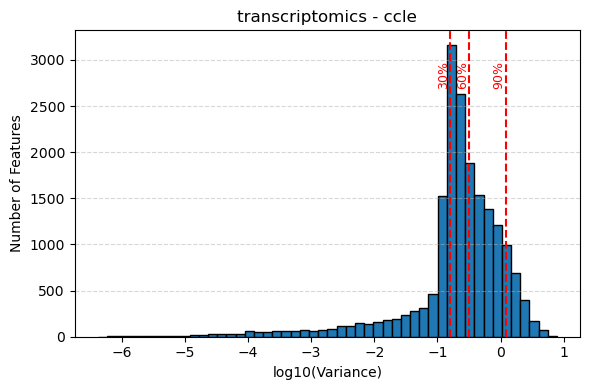

   ⚠️ ctrpv2: Removed 5 non-positive variances before log10 transform


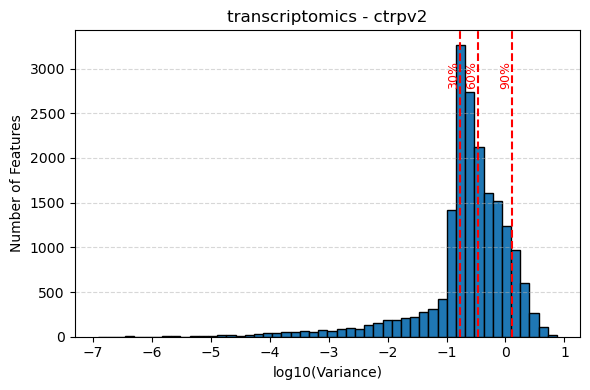

   ⚠️ fimm: Removed 165 non-positive variances before log10 transform


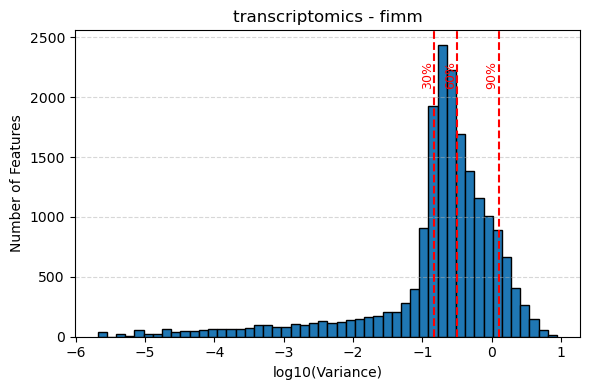

   ⚠️ gcsi: Removed 12 non-positive variances before log10 transform


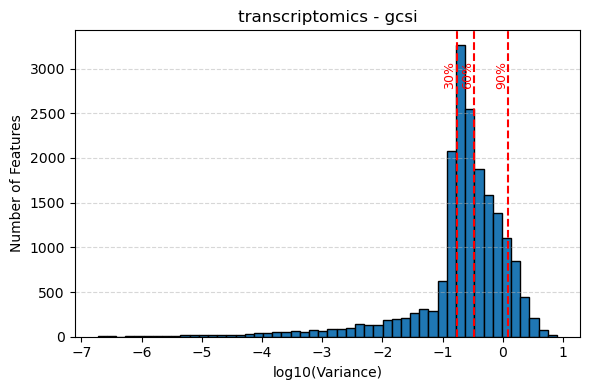

   ⚠️ gdscv1: Removed 84 non-positive variances before log10 transform


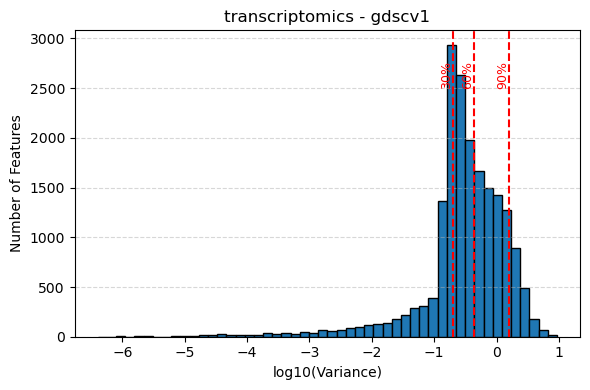

   ⚠️ gdscv2: Removed 86 non-positive variances before log10 transform


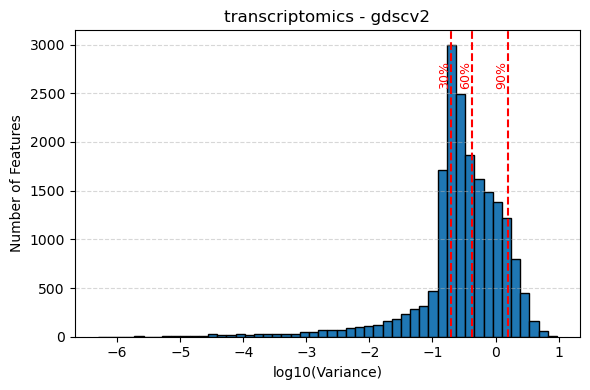

   ⚠️ liver: Removed 275 non-positive variances before log10 transform


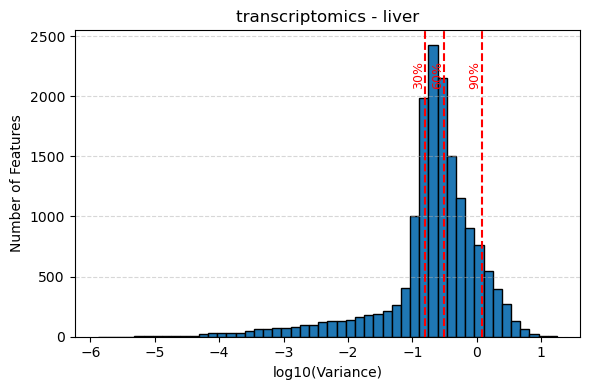

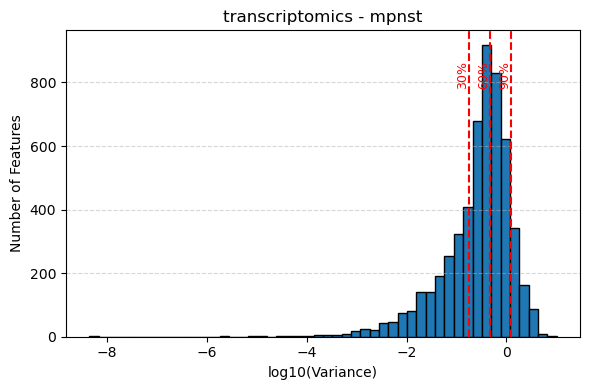

   ⚠️ nci60: Removed 155 non-positive variances before log10 transform


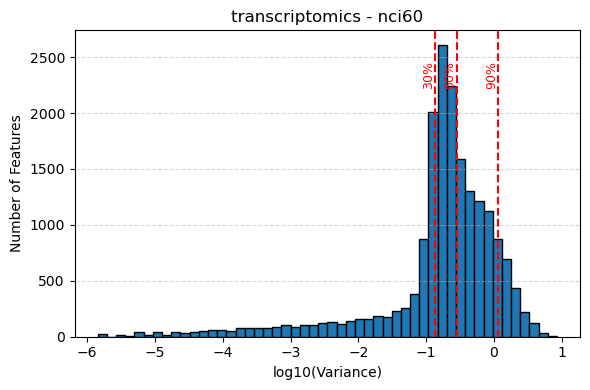

   ⚠️ prism: Removed 6 non-positive variances before log10 transform


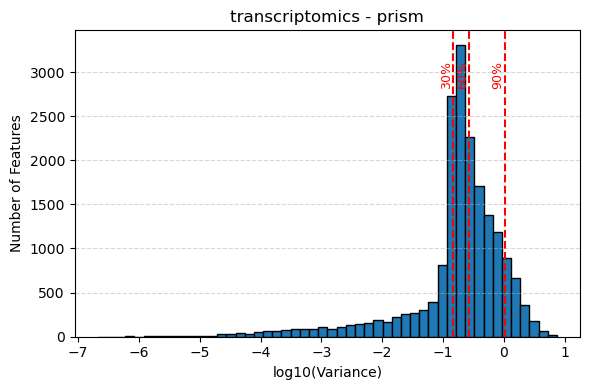

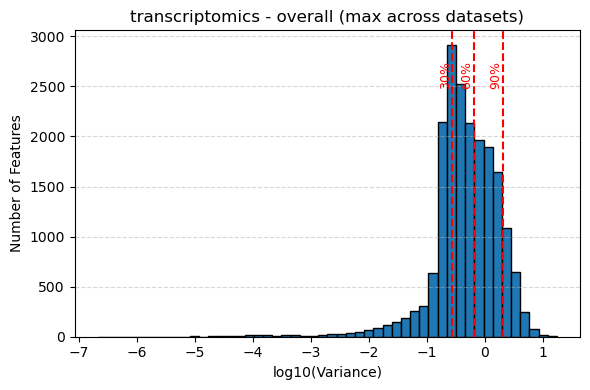

📊 Plotting variance distribution for feature group: proteomics


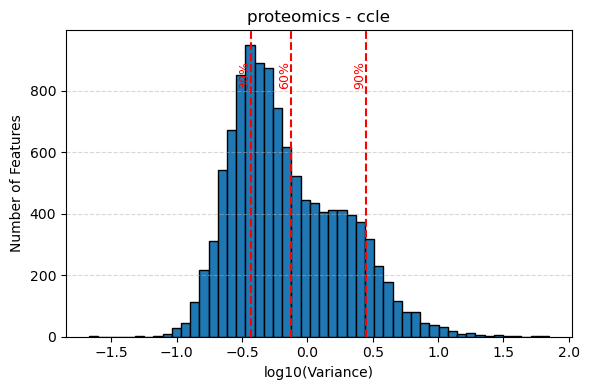

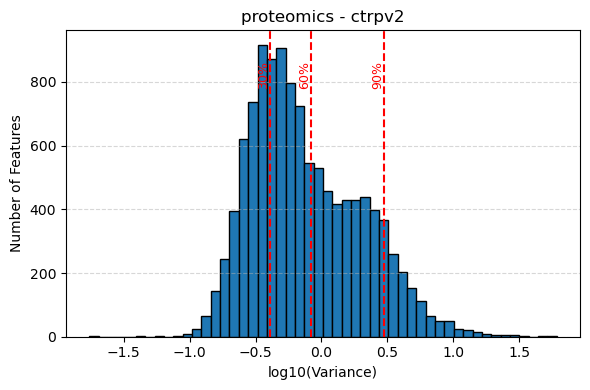

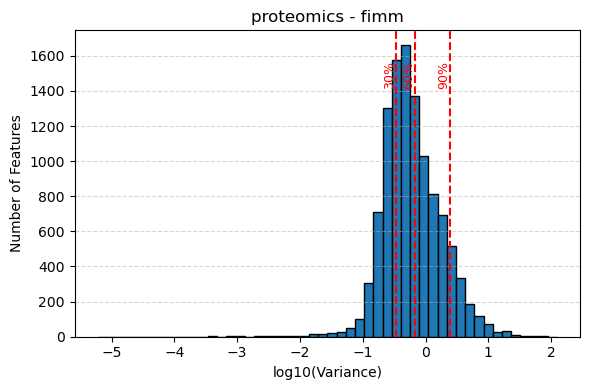

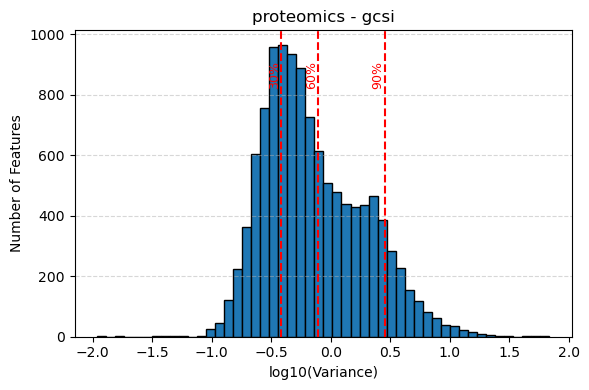

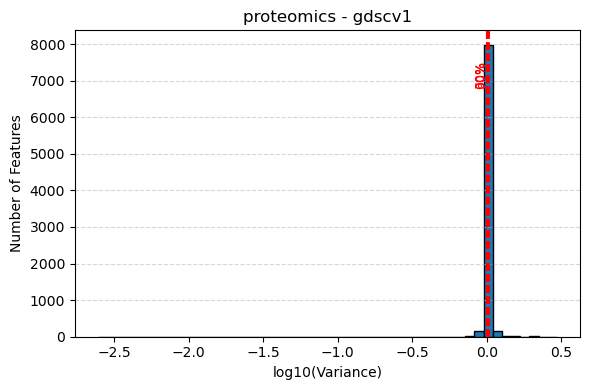

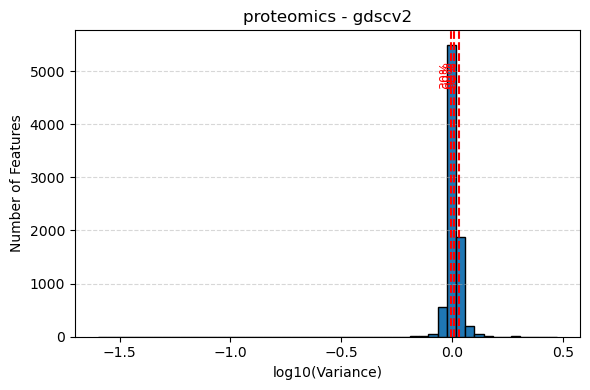

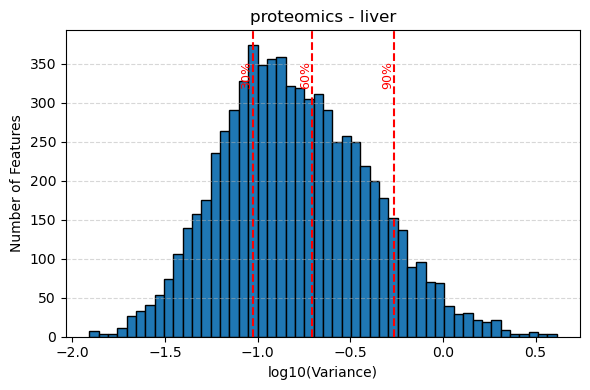

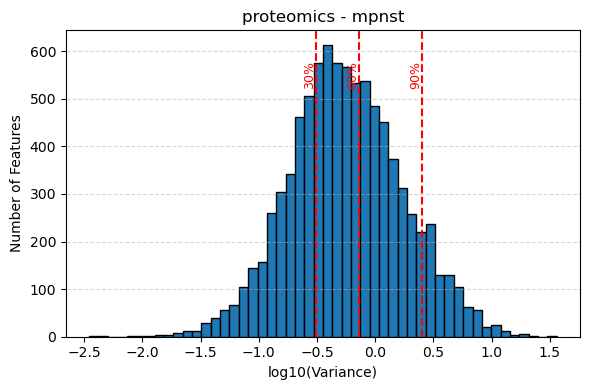

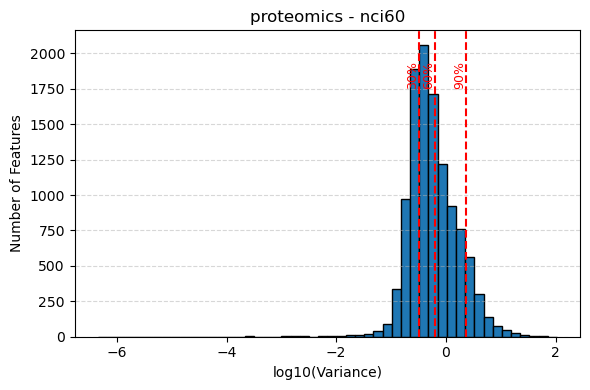

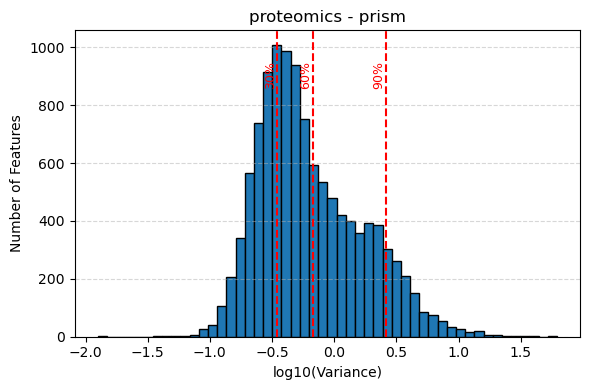

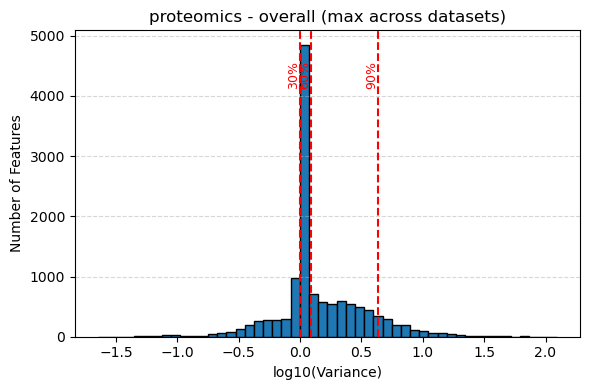

📊 Plotting variance distribution for feature group: copy_number


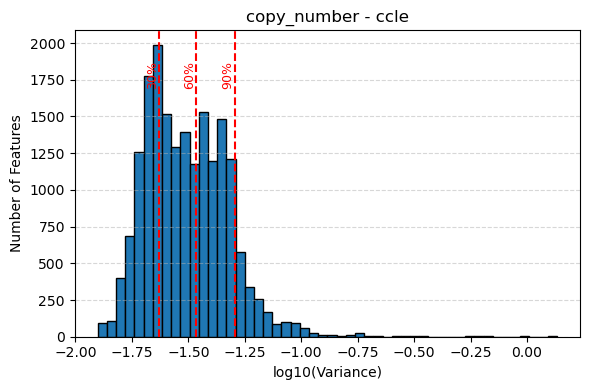

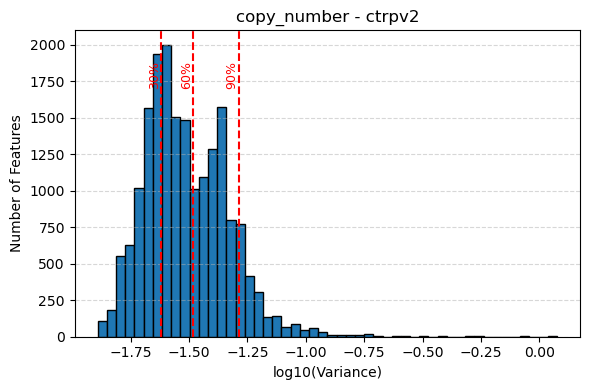

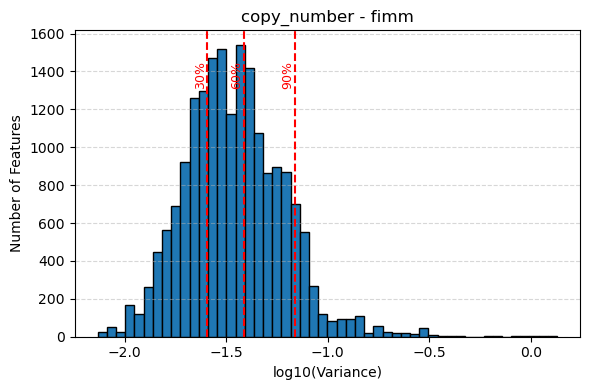

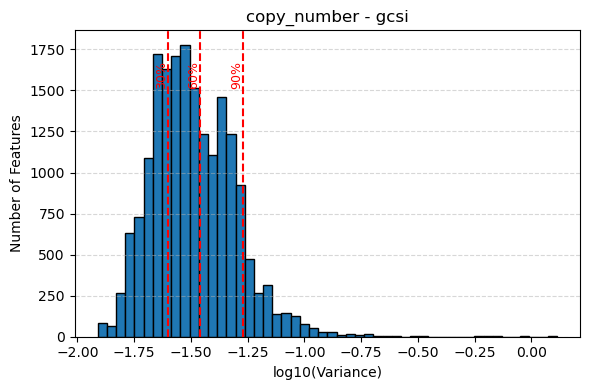

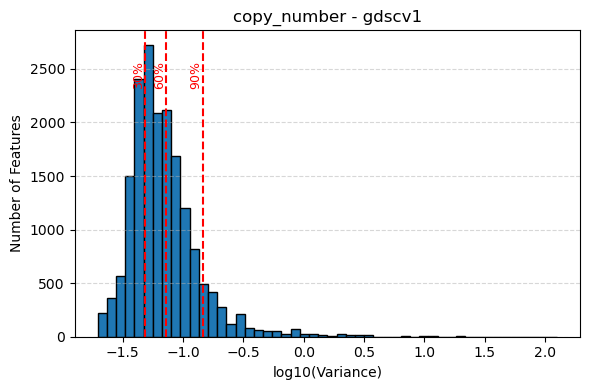

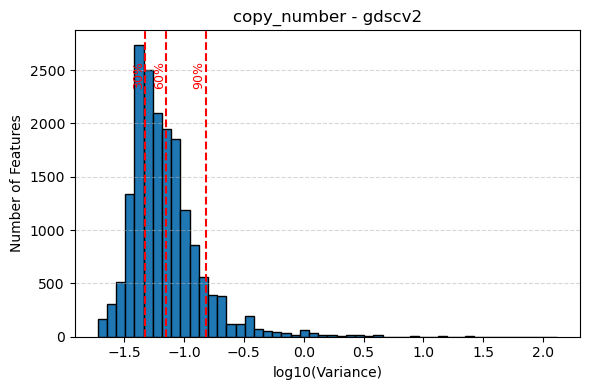

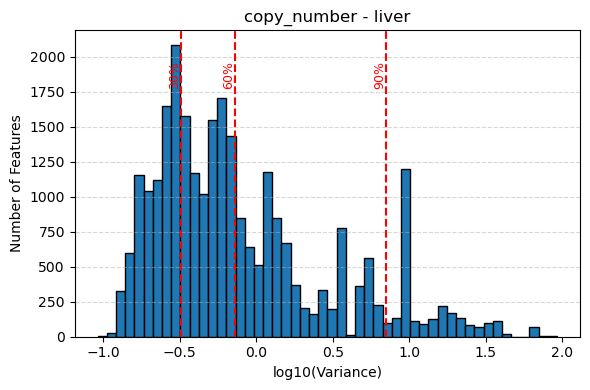

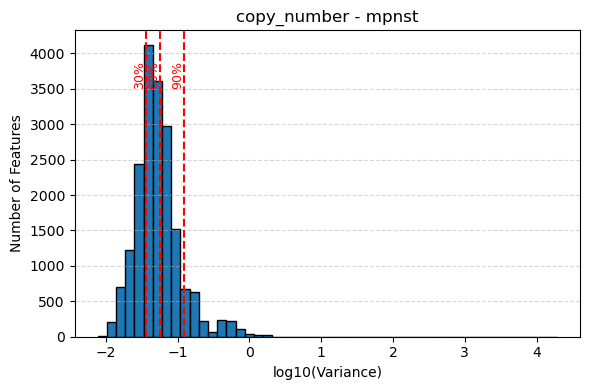

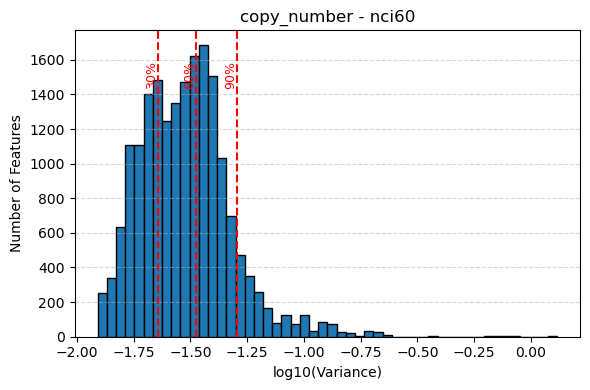

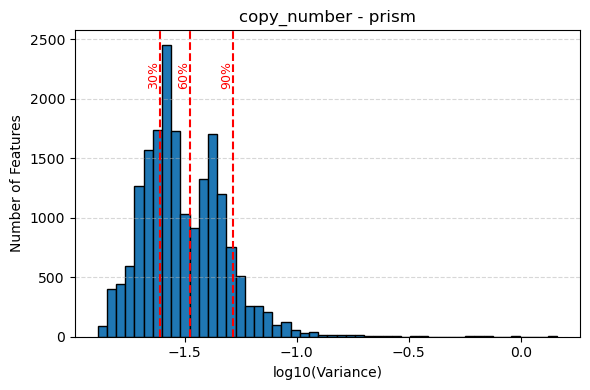

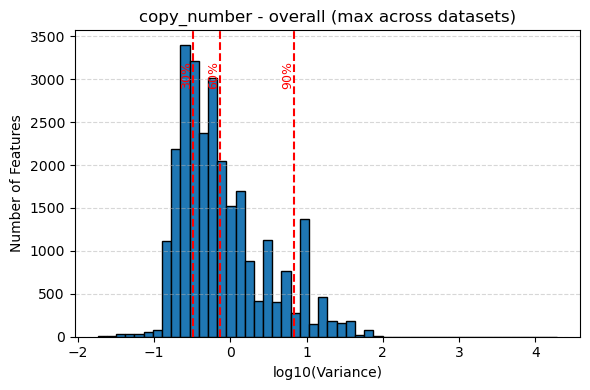

📊 Plotting variance distribution for feature group: mutations_Silent


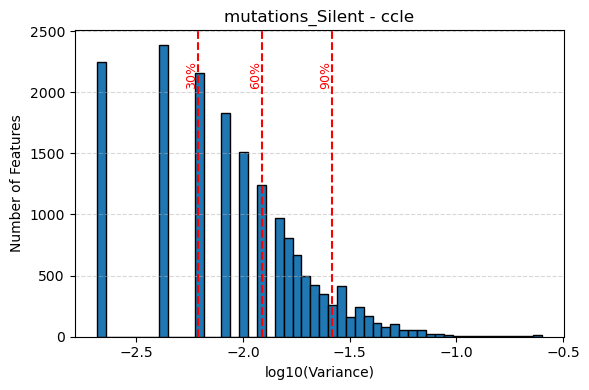

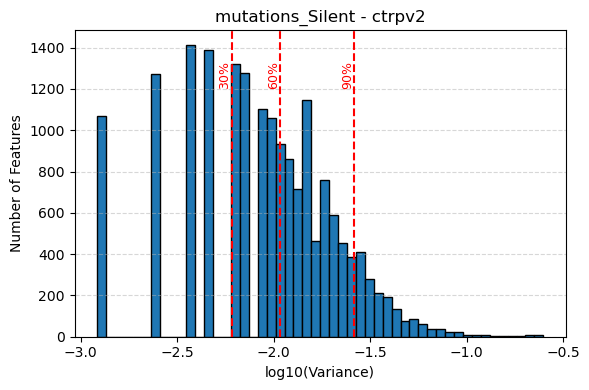

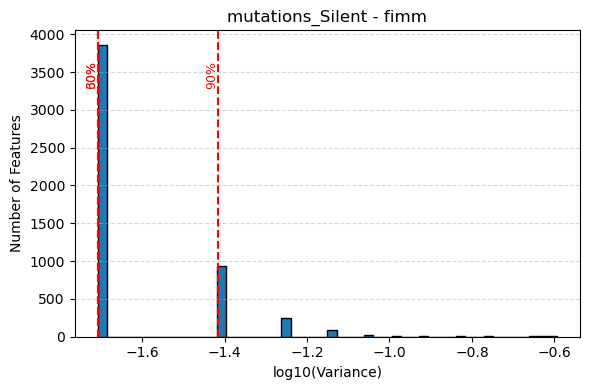

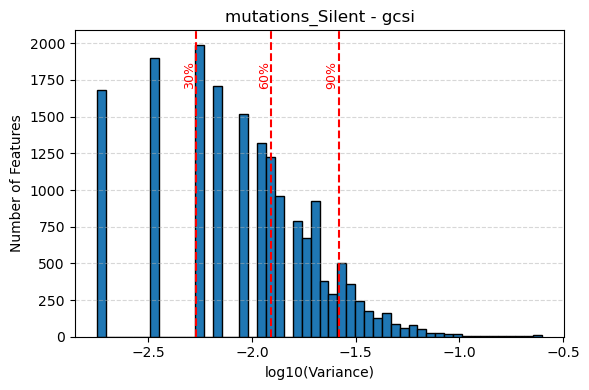

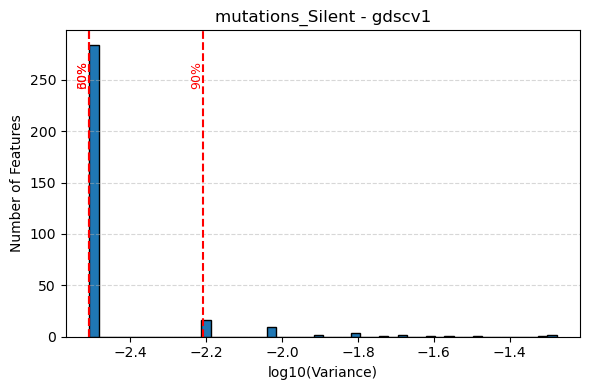

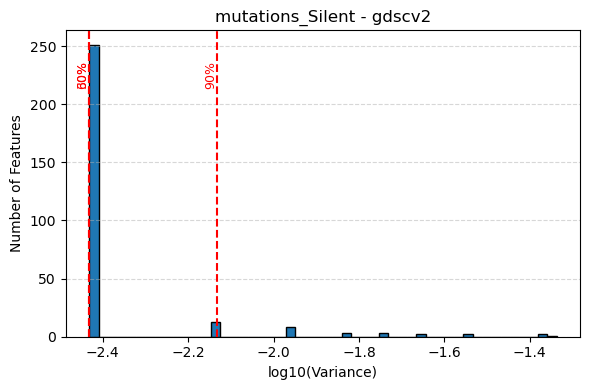

   ⚠️ Skipping mutations_Silent - liver: no positive variances to plot


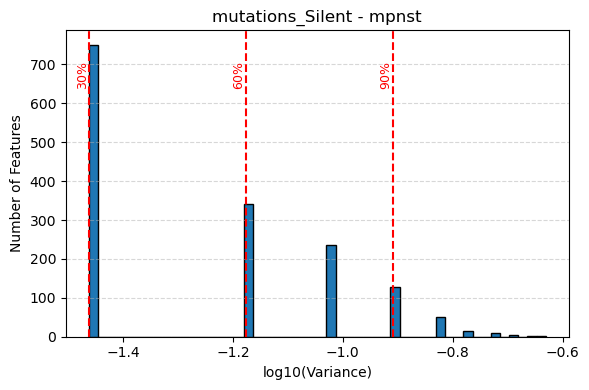

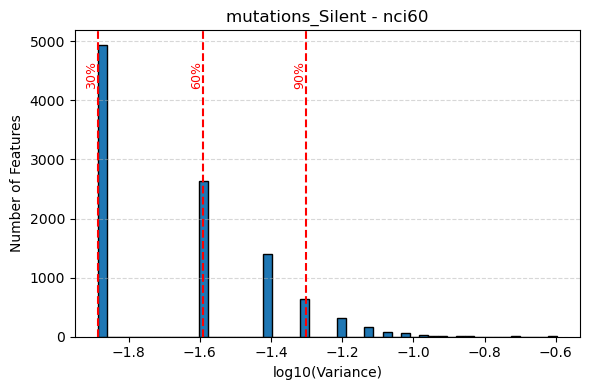

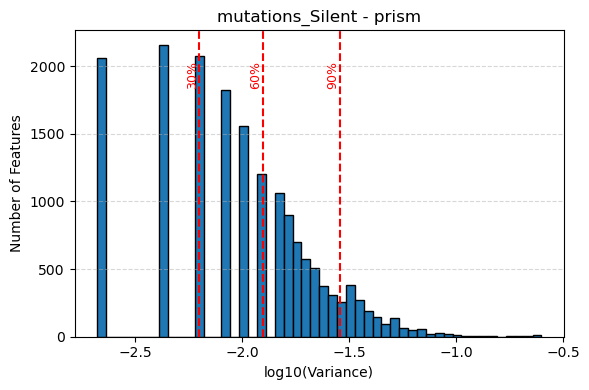

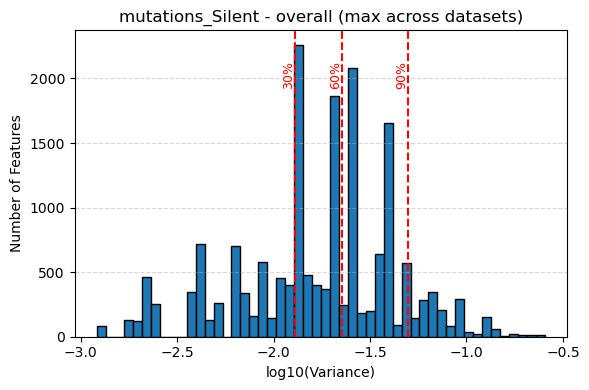

📊 Plotting variance distribution for feature group: mutations_5'Flank
   ⚠️ Skipping mutations_5'Flank - ccle: no positive variances to plot
   ⚠️ Skipping mutations_5'Flank - ctrpv2: no positive variances to plot
   ⚠️ Skipping mutations_5'Flank - fimm: no positive variances to plot
   ⚠️ Skipping mutations_5'Flank - gcsi: no positive variances to plot


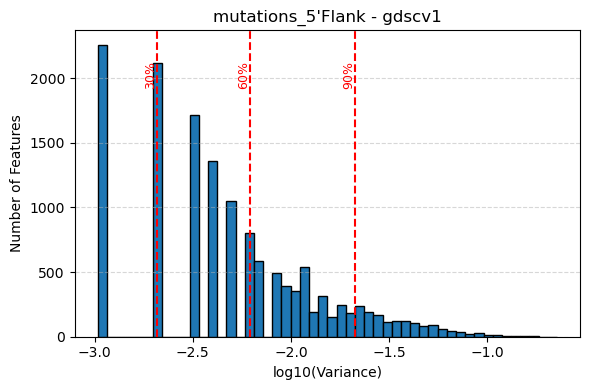

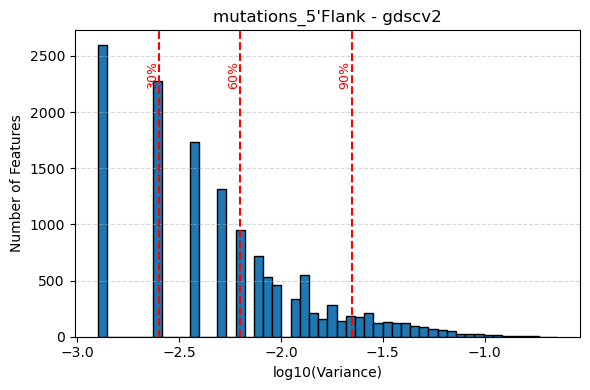

   ⚠️ Skipping mutations_5'Flank - liver: no positive variances to plot


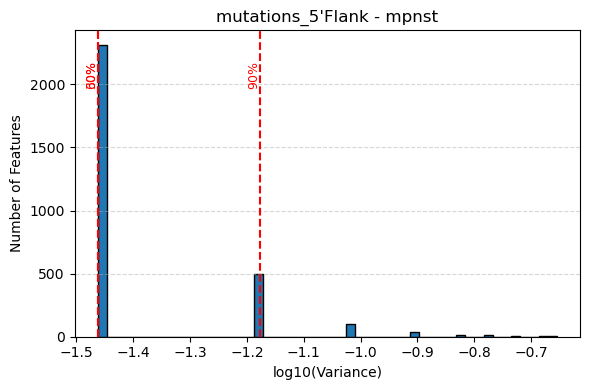

   ⚠️ Skipping mutations_5'Flank - nci60: no positive variances to plot
   ⚠️ Skipping mutations_5'Flank - prism: no positive variances to plot


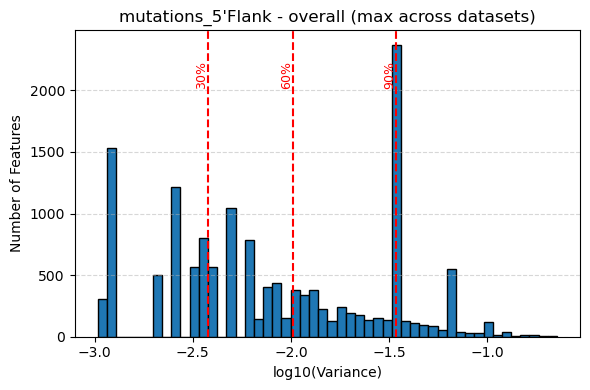

📊 Plotting variance distribution for feature group: mutations_Frame_Shift_Del


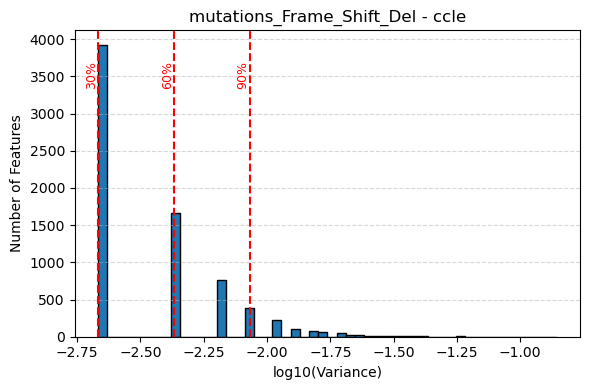

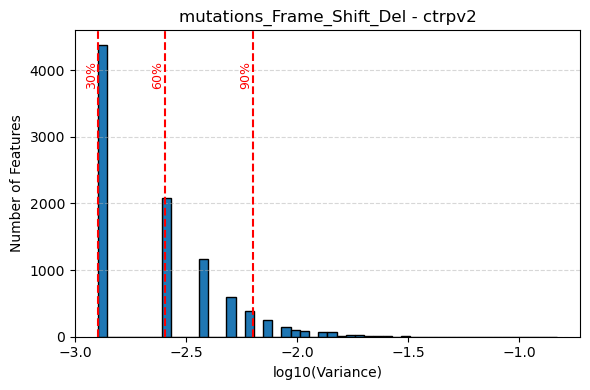

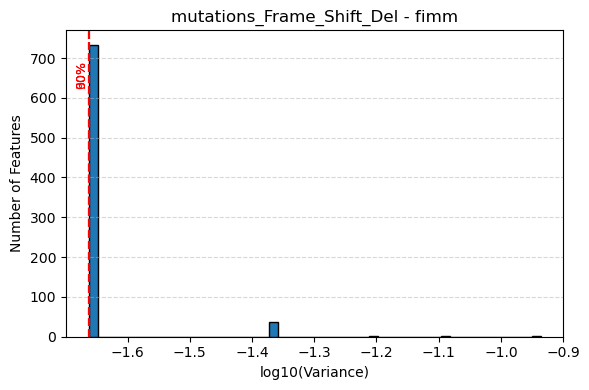

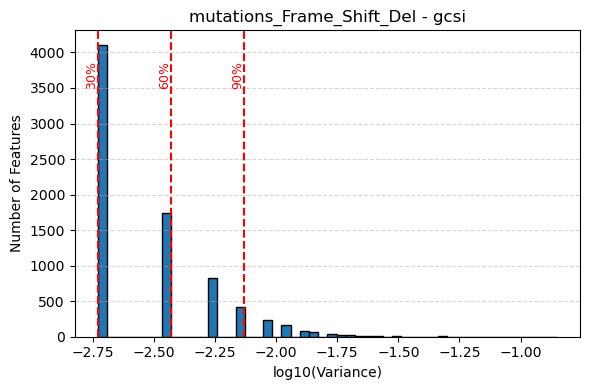

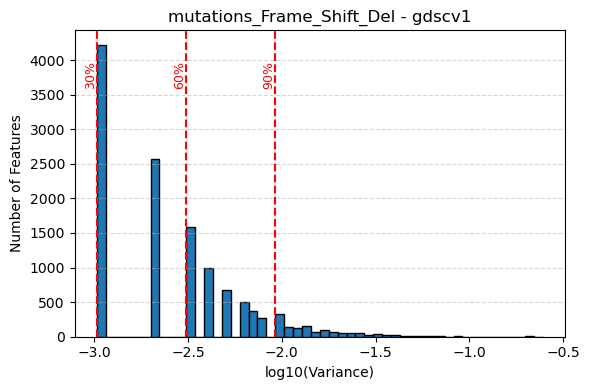

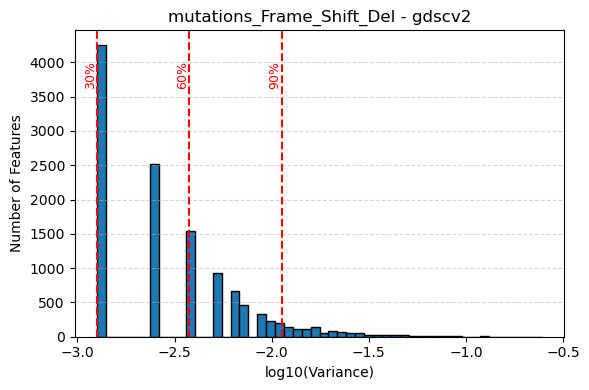

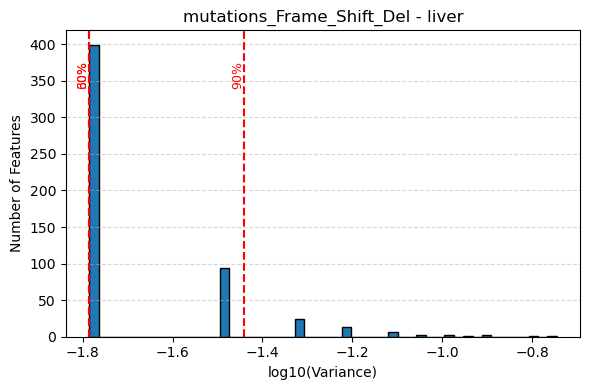

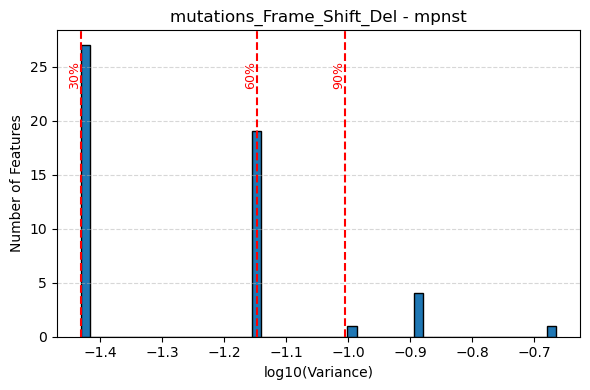

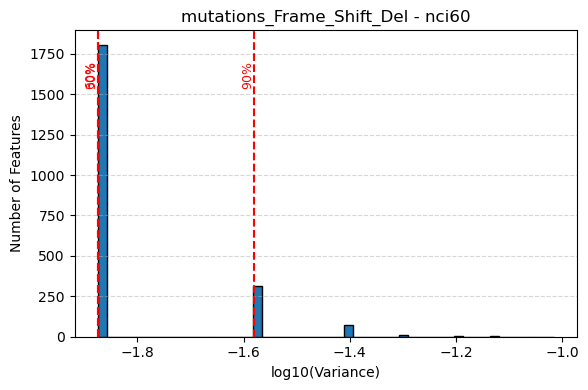

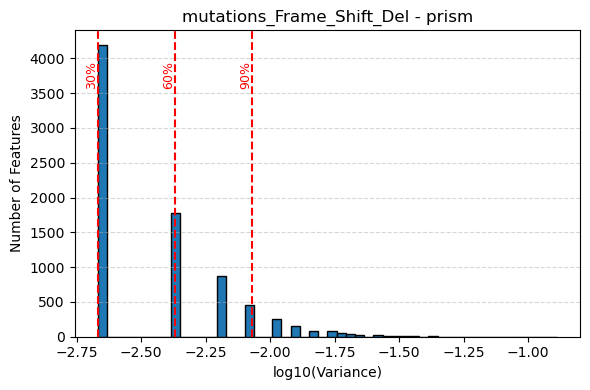

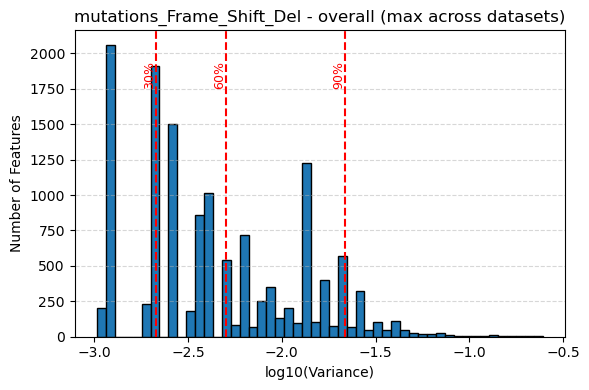

📊 Plotting variance distribution for feature group: mutations_Intron
   ⚠️ Skipping mutations_Intron - ccle: no positive variances to plot
   ⚠️ Skipping mutations_Intron - ctrpv2: no positive variances to plot
   ⚠️ Skipping mutations_Intron - fimm: no positive variances to plot
   ⚠️ Skipping mutations_Intron - gcsi: no positive variances to plot


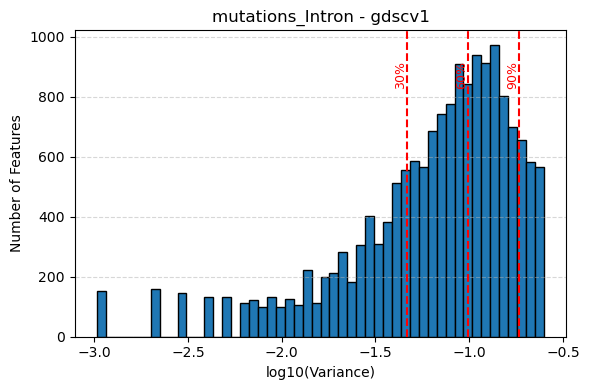

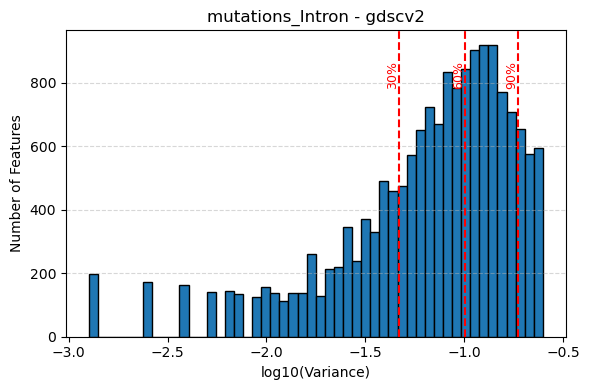

   ⚠️ Skipping mutations_Intron - liver: no positive variances to plot


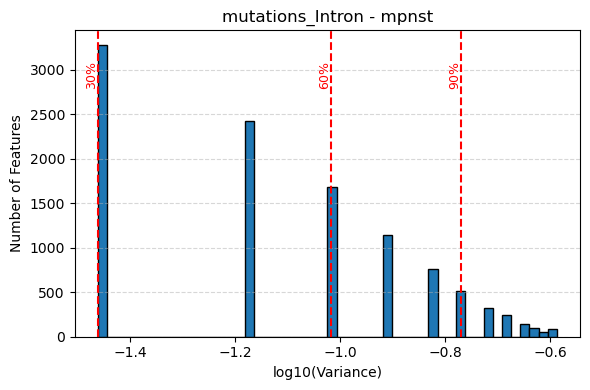

   ⚠️ Skipping mutations_Intron - nci60: no positive variances to plot
   ⚠️ Skipping mutations_Intron - prism: no positive variances to plot


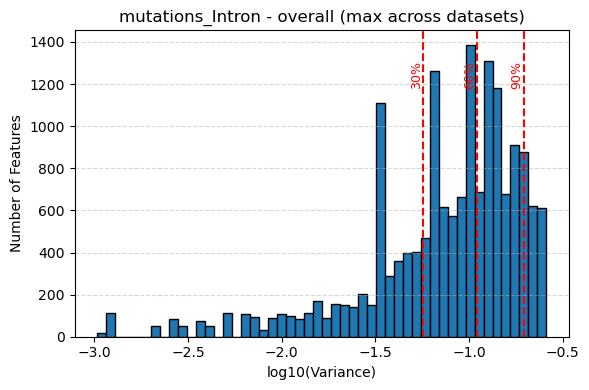

📊 Plotting variance distribution for feature group: mutations_Missense_Mutation


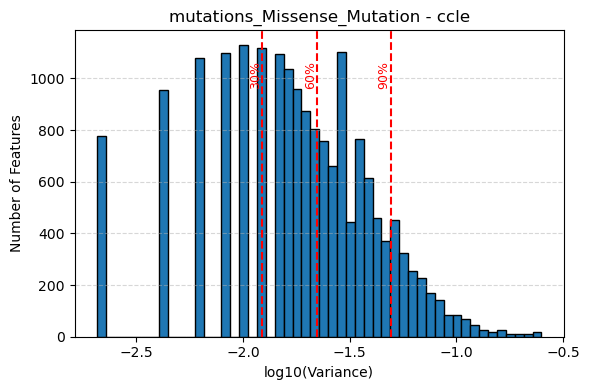

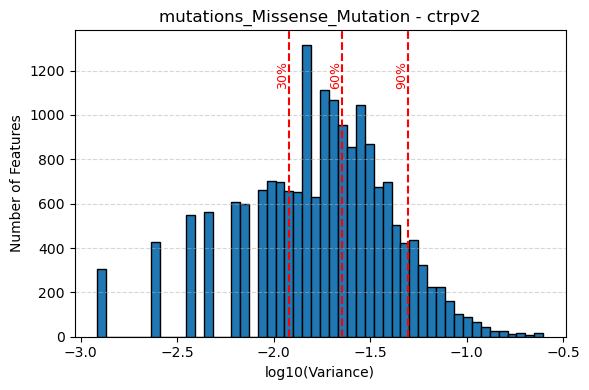

   ⚠️ fimm: Removed 1 non-positive variances before log10 transform


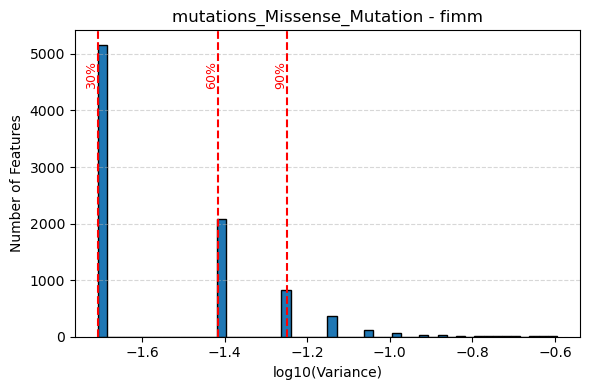

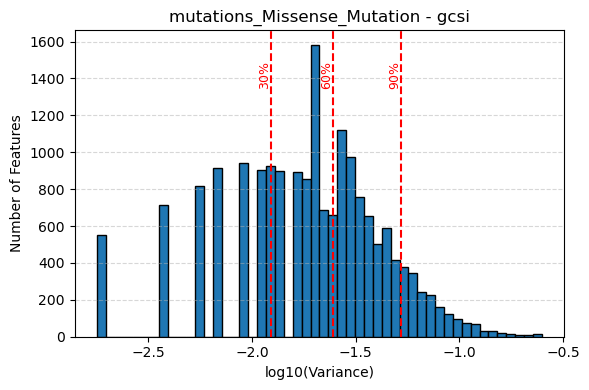

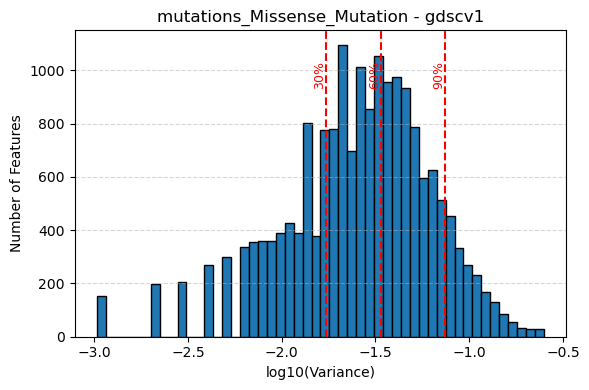

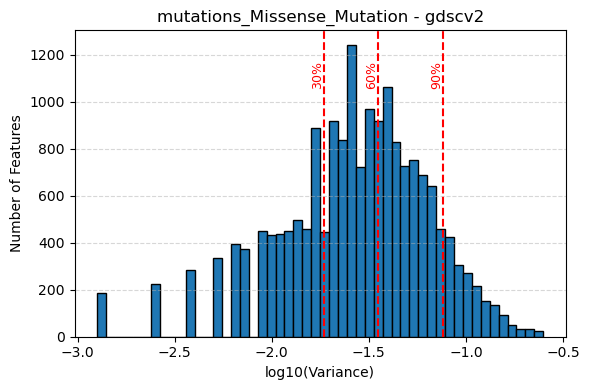

   ⚠️ liver: Removed 3 non-positive variances before log10 transform


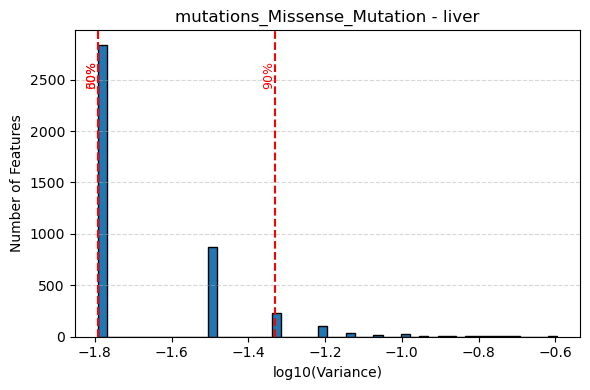

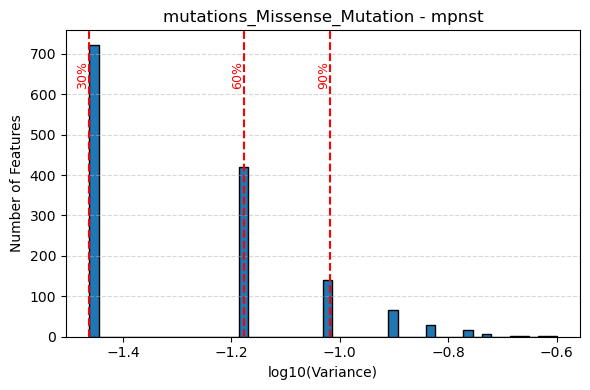

   ⚠️ nci60: Removed 1 non-positive variances before log10 transform


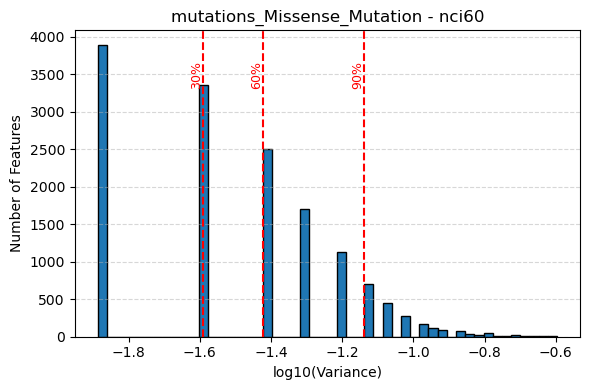

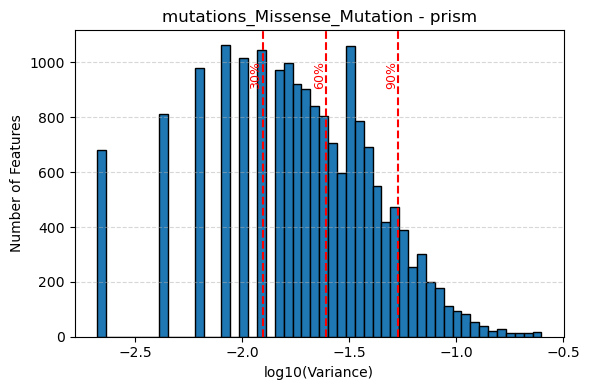

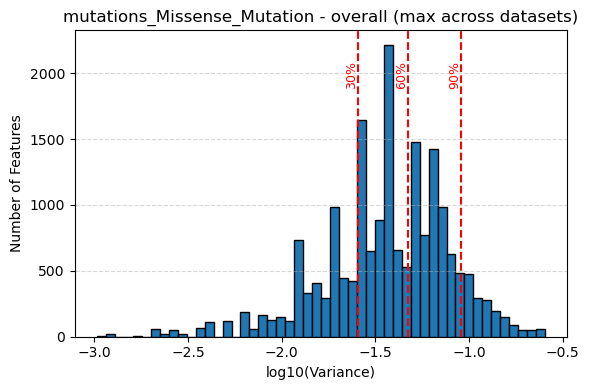

📊 Plotting variance distribution for feature group: mutations_Nonstop_Mutation


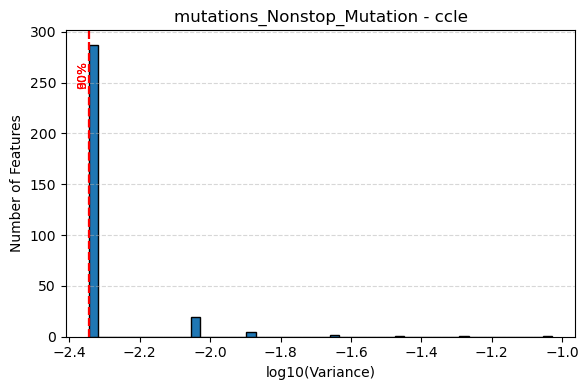

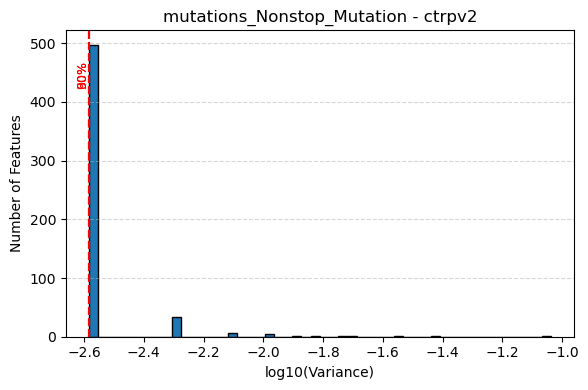

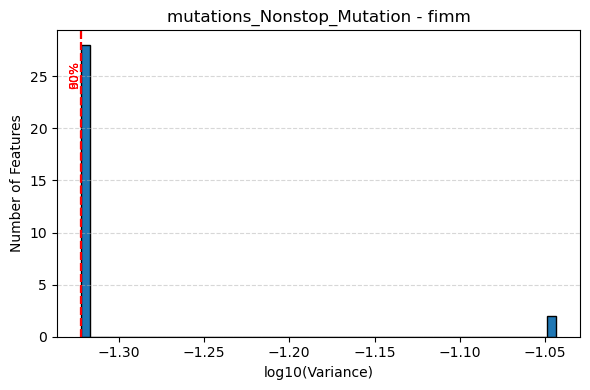

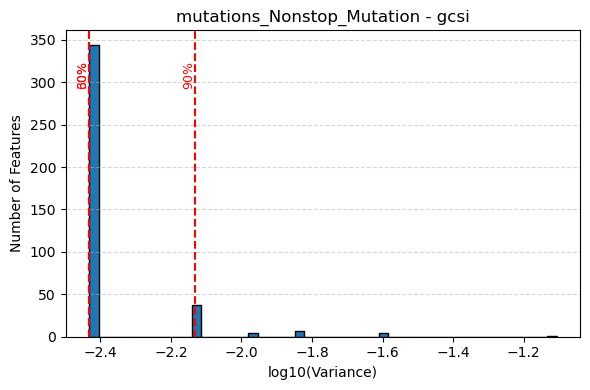

   ⚠️ Skipping mutations_Nonstop_Mutation - gdscv1: no positive variances to plot
   ⚠️ Skipping mutations_Nonstop_Mutation - gdscv2: no positive variances to plot


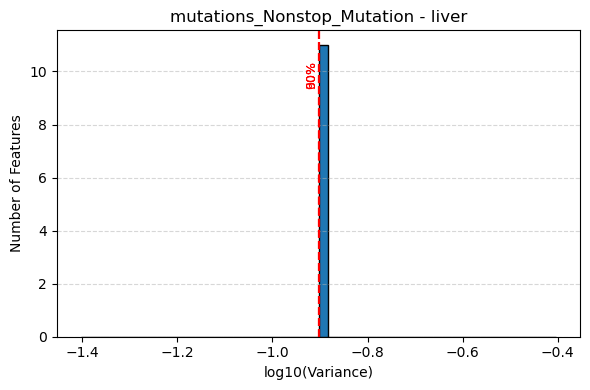

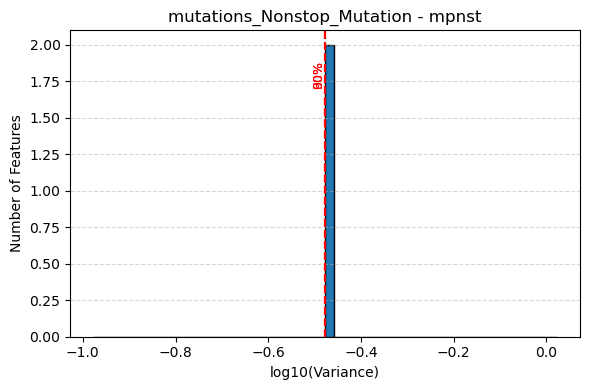

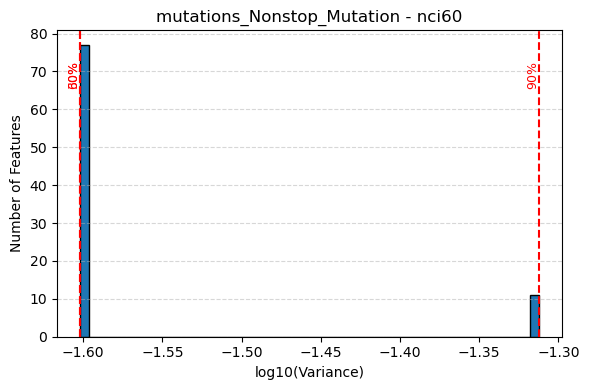

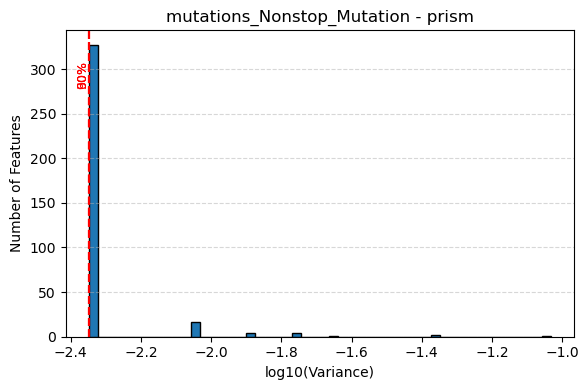

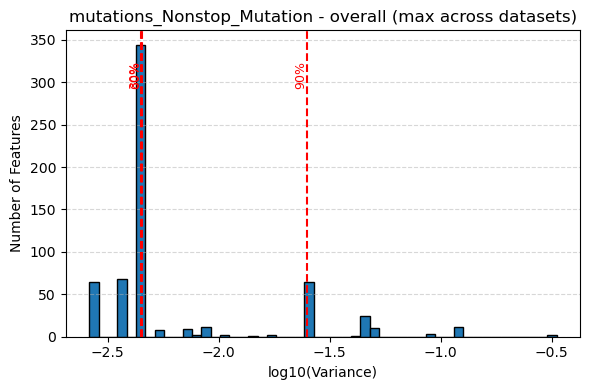

📊 Plotting variance distribution for feature group: mutations_5'UTR
   ⚠️ Skipping mutations_5'UTR - ccle: no positive variances to plot
   ⚠️ Skipping mutations_5'UTR - ctrpv2: no positive variances to plot
   ⚠️ Skipping mutations_5'UTR - fimm: no positive variances to plot
   ⚠️ Skipping mutations_5'UTR - gcsi: no positive variances to plot


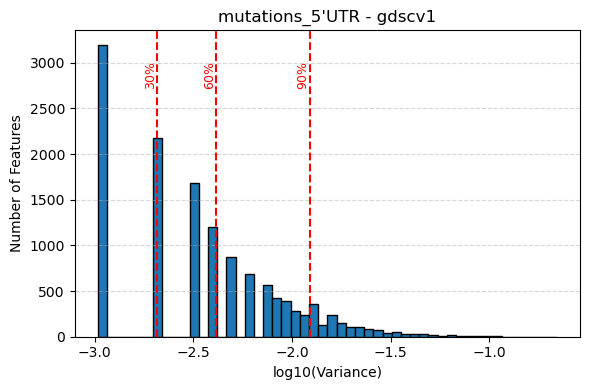

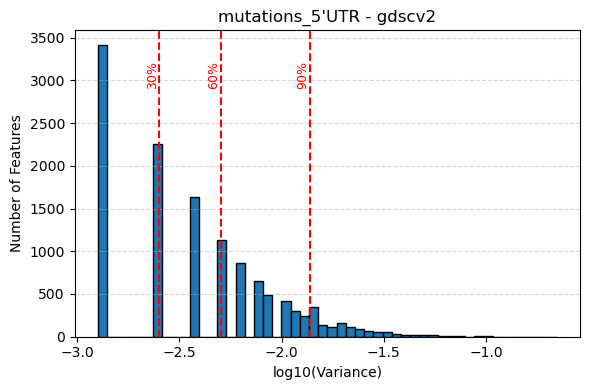

   ⚠️ Skipping mutations_5'UTR - liver: no positive variances to plot


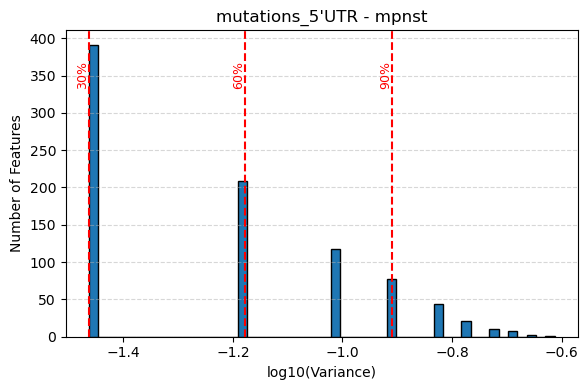

   ⚠️ Skipping mutations_5'UTR - nci60: no positive variances to plot
   ⚠️ Skipping mutations_5'UTR - prism: no positive variances to plot


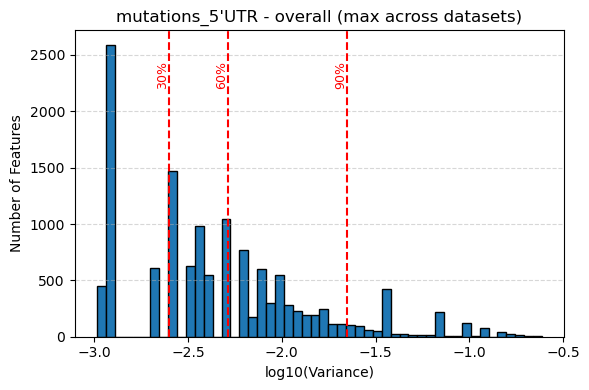

📊 Plotting variance distribution for feature group: mutations_Nonsense_Mutation


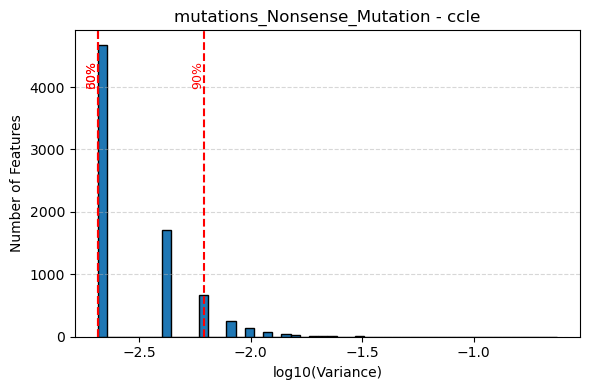

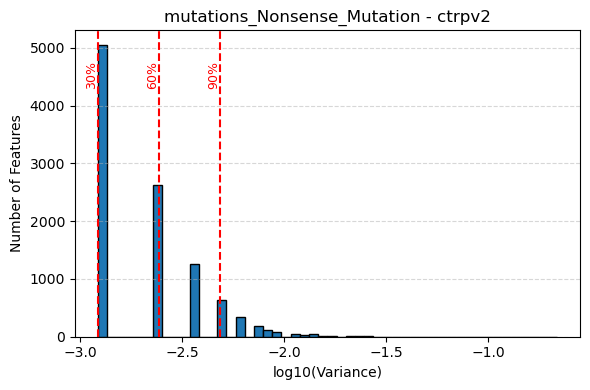

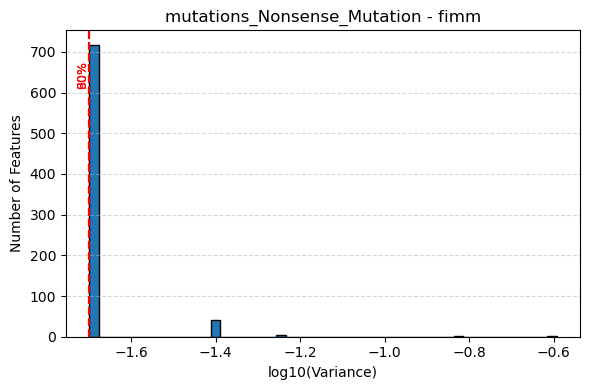

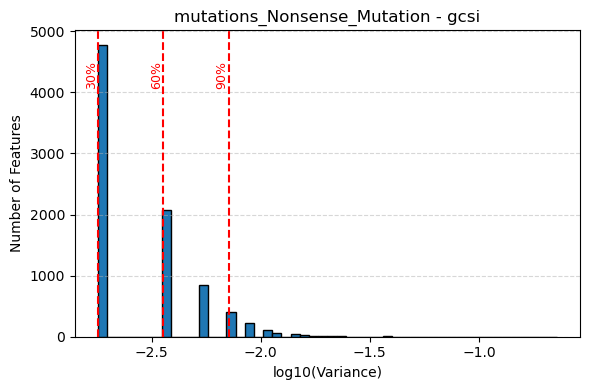

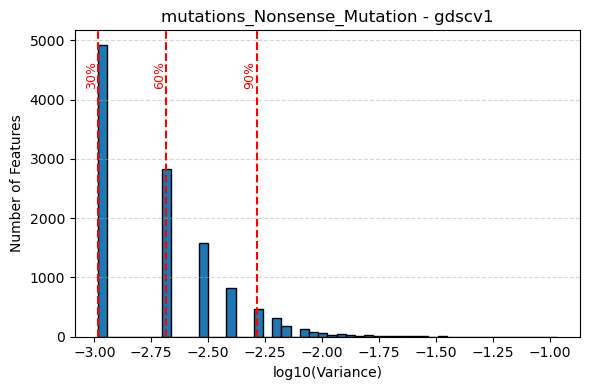

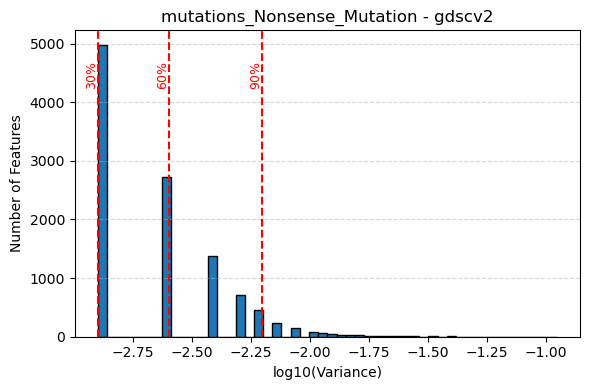

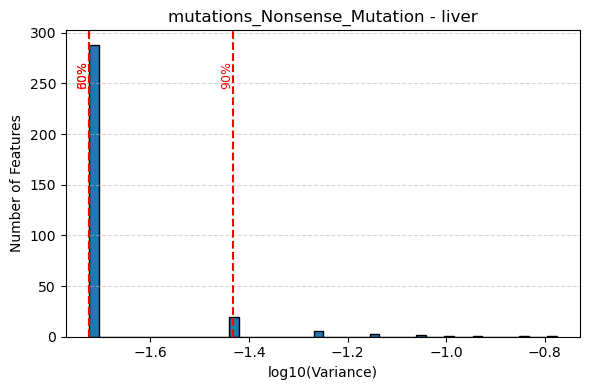

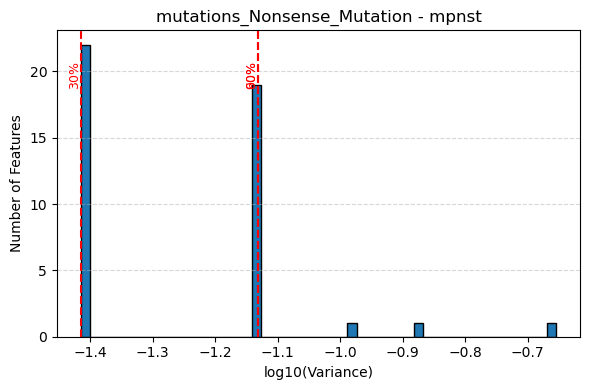

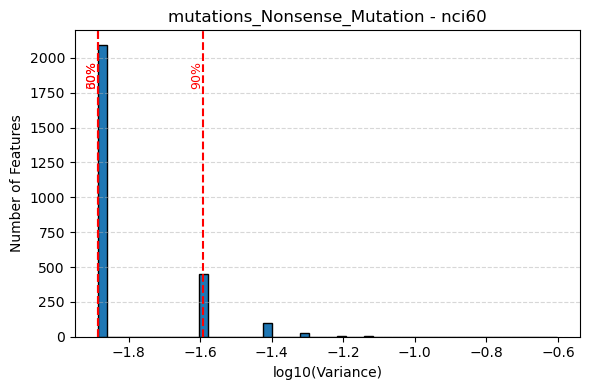

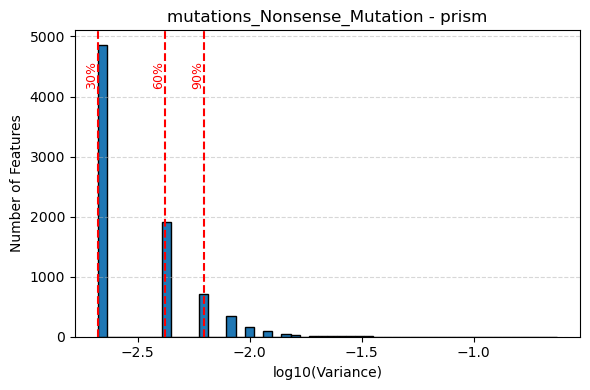

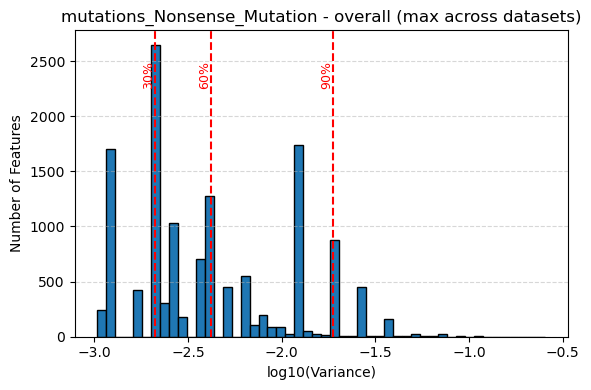

📊 Plotting variance distribution for feature group: mutations_In_Frame_Ins


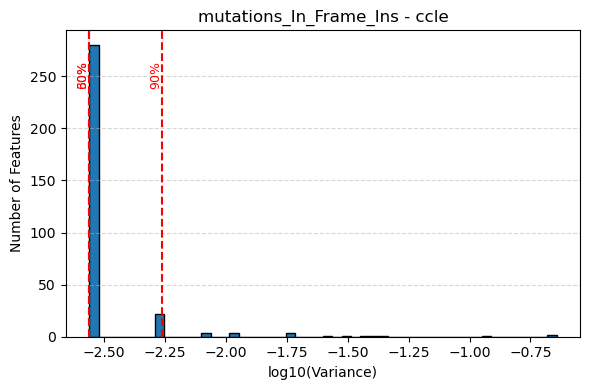

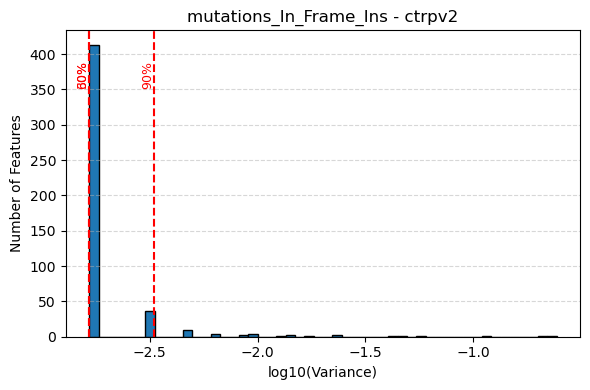

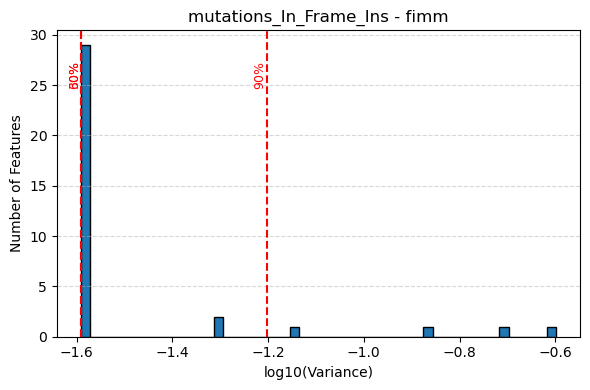

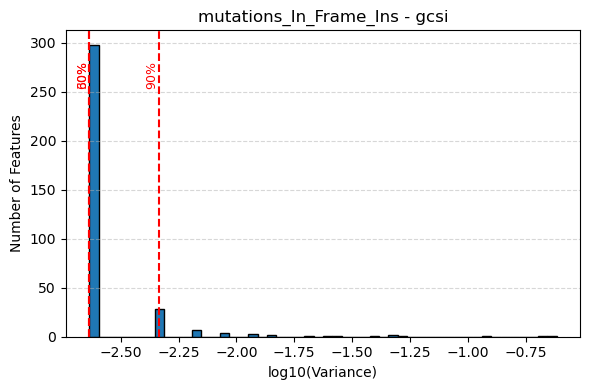

   ⚠️ Skipping mutations_In_Frame_Ins - gdscv1: no positive variances to plot
   ⚠️ Skipping mutations_In_Frame_Ins - gdscv2: no positive variances to plot


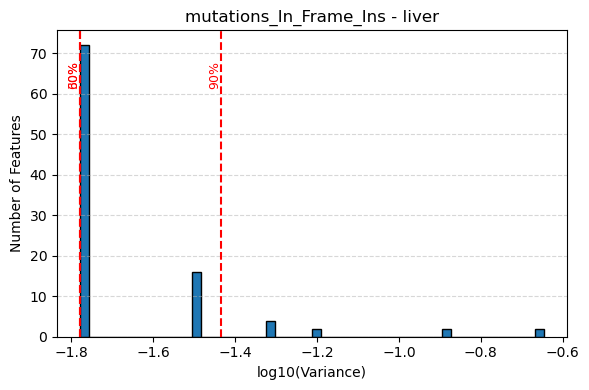

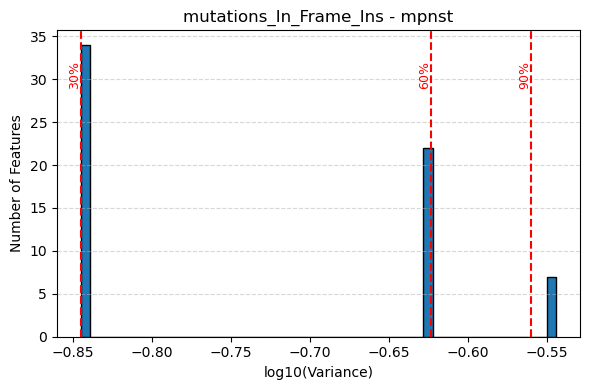

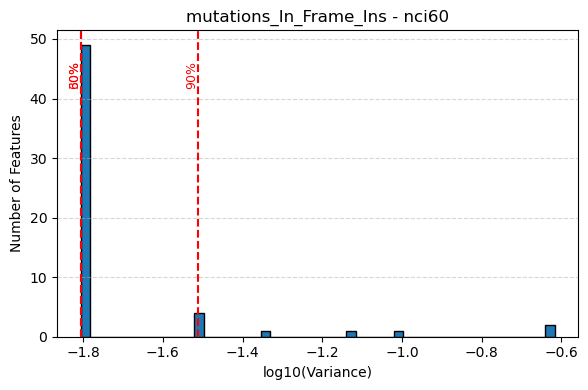

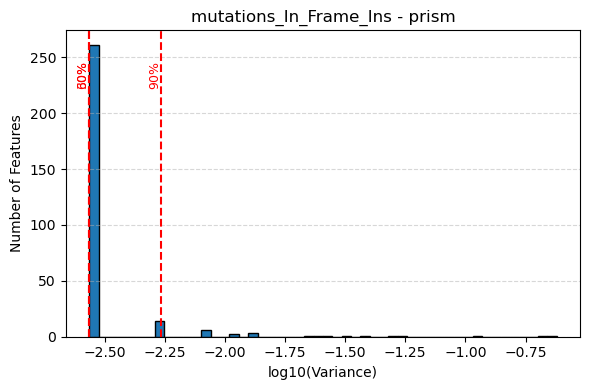

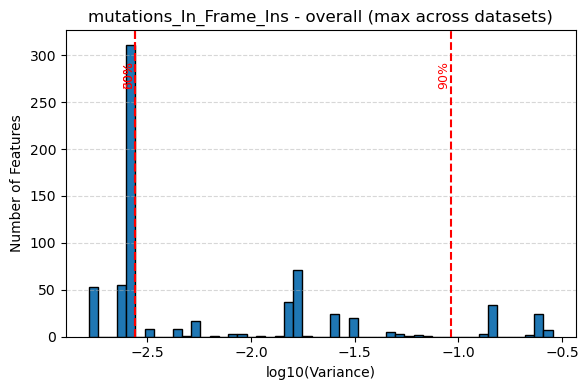

📊 Plotting variance distribution for feature group: mutations_Frame_Shift_Ins


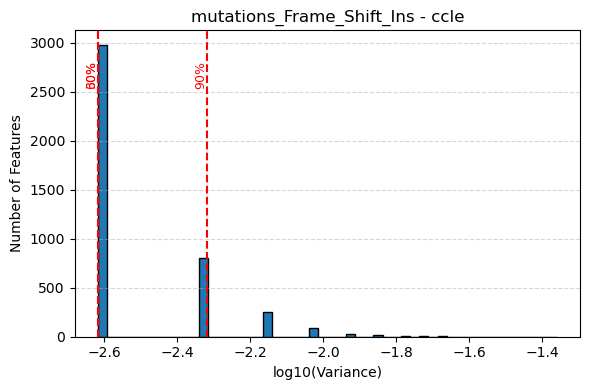

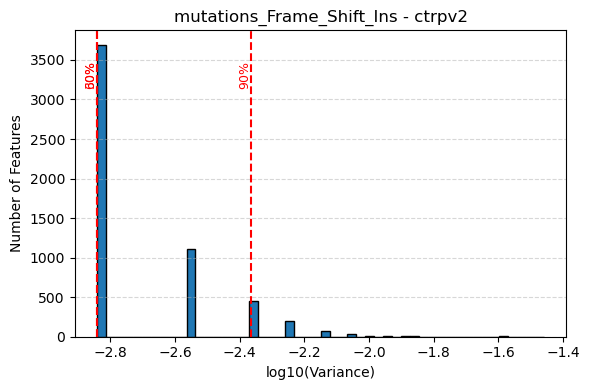

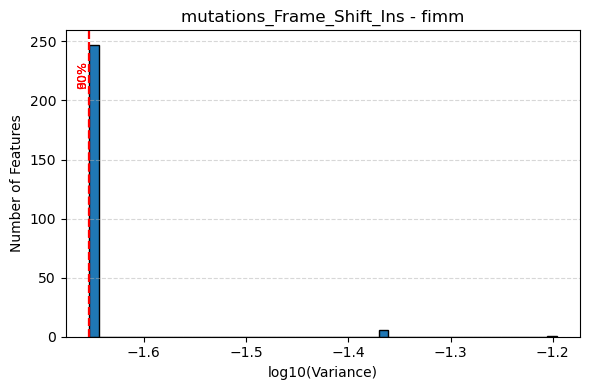

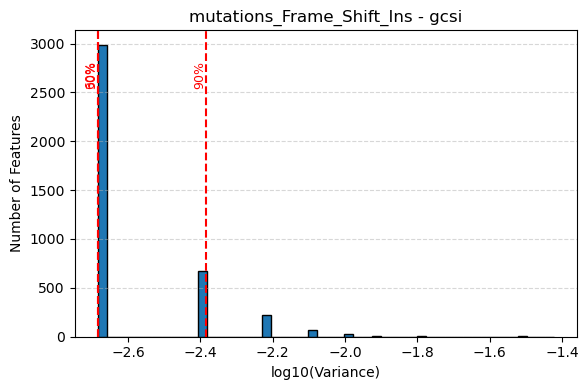

   ⚠️ Skipping mutations_Frame_Shift_Ins - gdscv1: no positive variances to plot
   ⚠️ Skipping mutations_Frame_Shift_Ins - gdscv2: no positive variances to plot


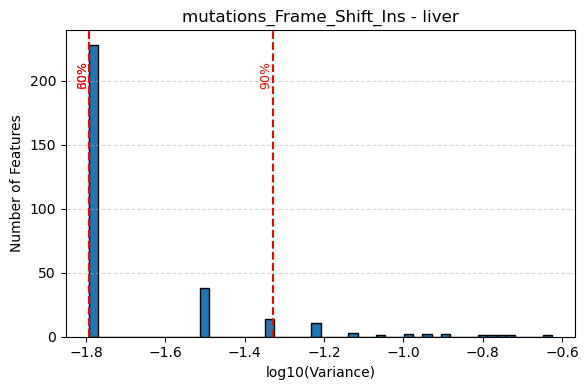

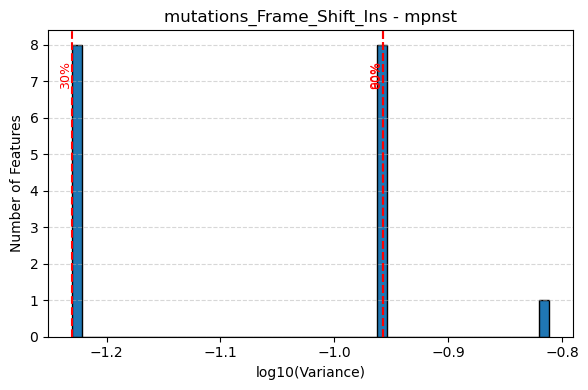

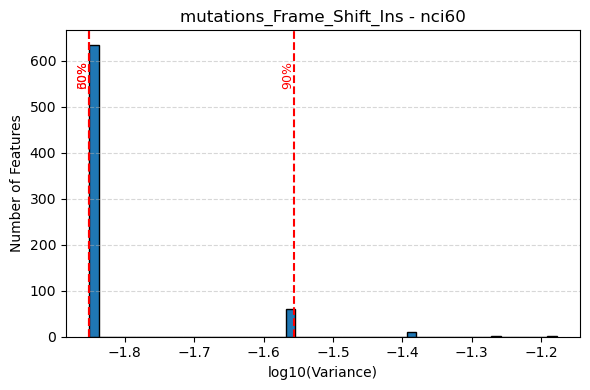

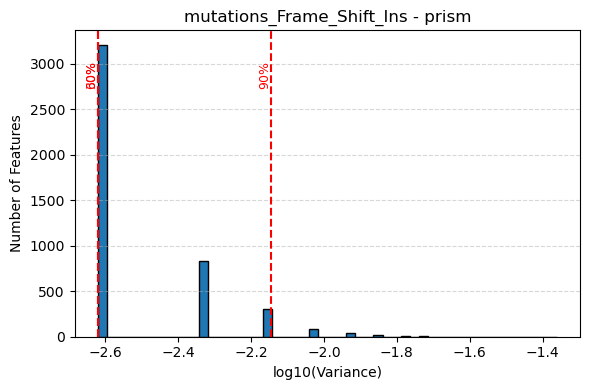

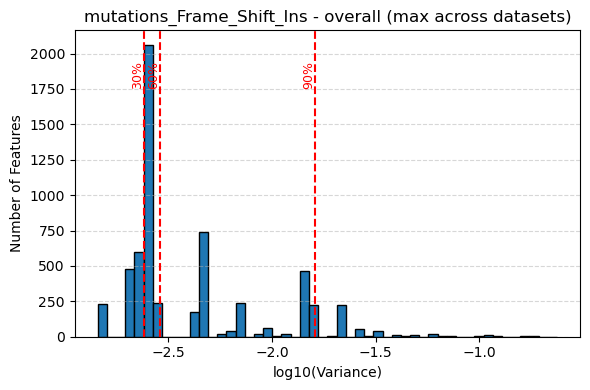

📊 Plotting variance distribution for feature group: mutations_3'UTR
   ⚠️ Skipping mutations_3'UTR - ccle: no positive variances to plot
   ⚠️ Skipping mutations_3'UTR - ctrpv2: no positive variances to plot
   ⚠️ Skipping mutations_3'UTR - fimm: no positive variances to plot
   ⚠️ Skipping mutations_3'UTR - gcsi: no positive variances to plot


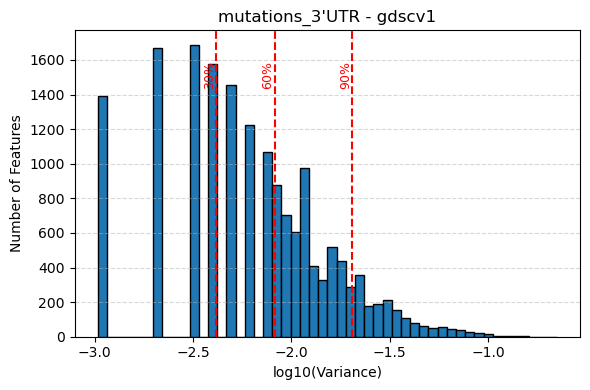

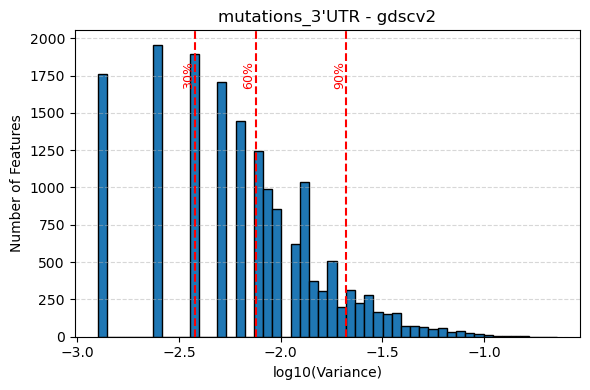

   ⚠️ Skipping mutations_3'UTR - liver: no positive variances to plot


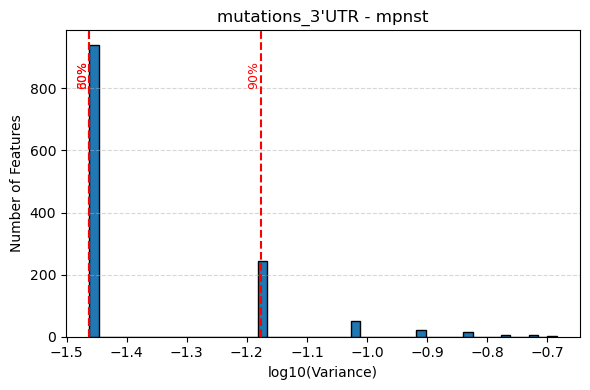

   ⚠️ Skipping mutations_3'UTR - nci60: no positive variances to plot
   ⚠️ Skipping mutations_3'UTR - prism: no positive variances to plot


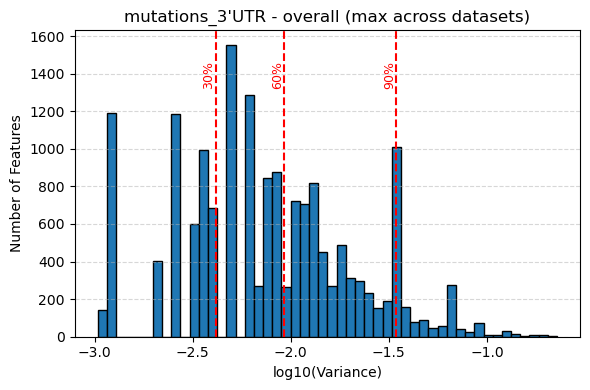

📊 Plotting variance distribution for feature group: mutations_Translation_Start_Site
   ⚠️ Skipping mutations_Translation_Start_Site - ccle: no positive variances to plot
   ⚠️ Skipping mutations_Translation_Start_Site - ctrpv2: no positive variances to plot
   ⚠️ Skipping mutations_Translation_Start_Site - fimm: no positive variances to plot
   ⚠️ Skipping mutations_Translation_Start_Site - gcsi: no positive variances to plot


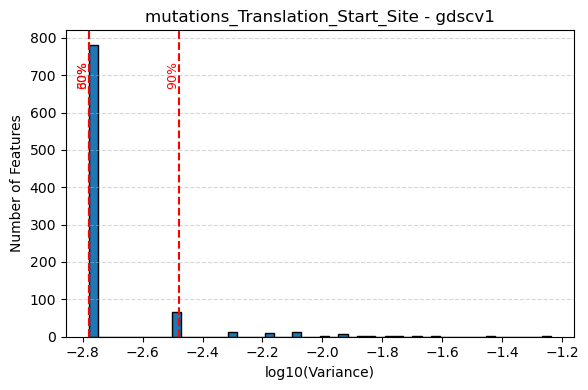

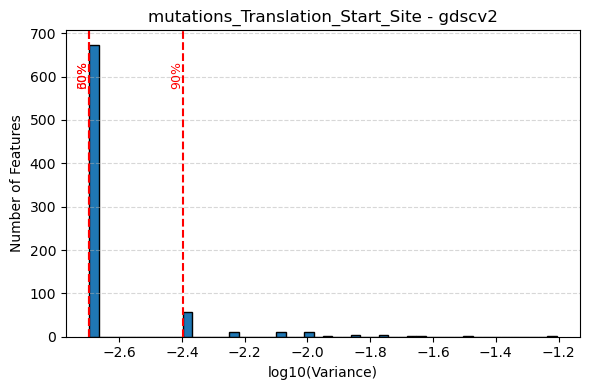

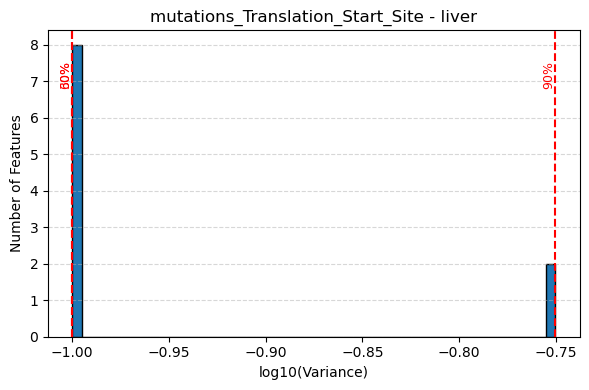

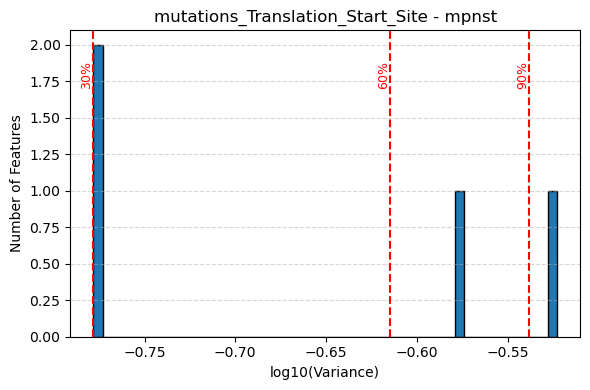

   ⚠️ Skipping mutations_Translation_Start_Site - nci60: no positive variances to plot
   ⚠️ Skipping mutations_Translation_Start_Site - prism: no positive variances to plot


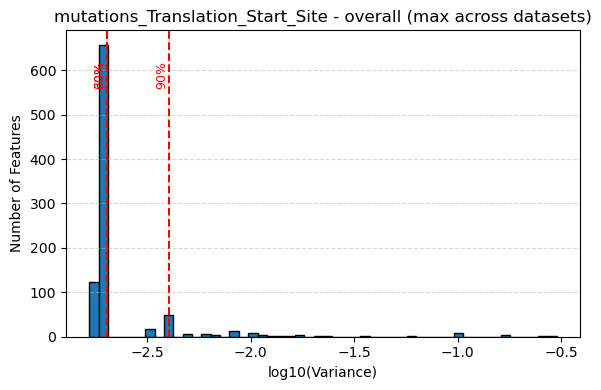

📊 Plotting variance distribution for feature group: mutations_Splice_Region
   ⚠️ Skipping mutations_Splice_Region - ccle: no positive variances to plot
   ⚠️ Skipping mutations_Splice_Region - ctrpv2: no positive variances to plot
   ⚠️ Skipping mutations_Splice_Region - fimm: no positive variances to plot
   ⚠️ Skipping mutations_Splice_Region - gcsi: no positive variances to plot
   ⚠️ Skipping mutations_Splice_Region - gdscv1: no positive variances to plot
   ⚠️ Skipping mutations_Splice_Region - gdscv2: no positive variances to plot
   ⚠️ Skipping mutations_Splice_Region - liver: no positive variances to plot


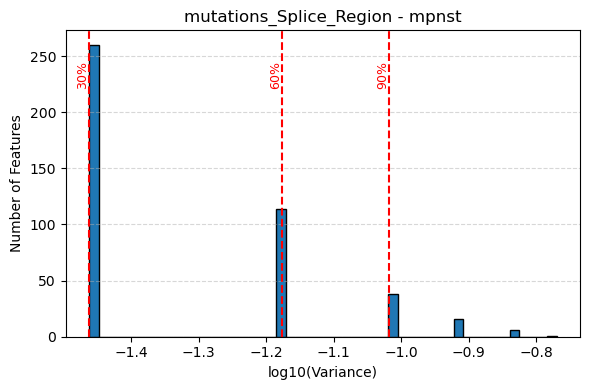

   ⚠️ Skipping mutations_Splice_Region - nci60: no positive variances to plot
   ⚠️ Skipping mutations_Splice_Region - prism: no positive variances to plot


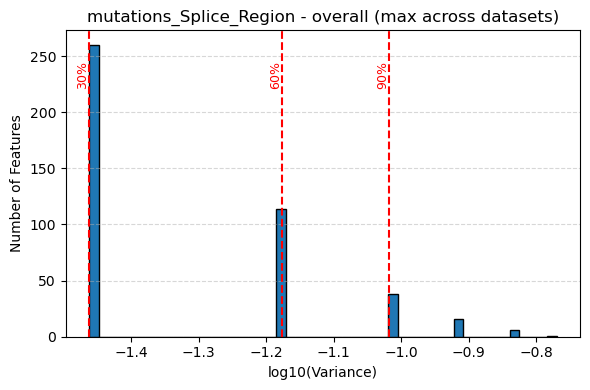

📊 Plotting variance distribution for feature group: mutations_Splice_Site


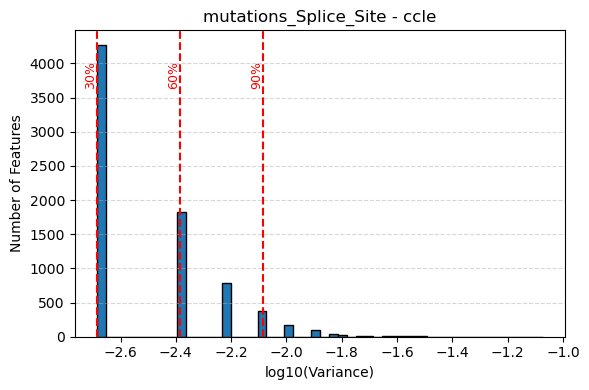

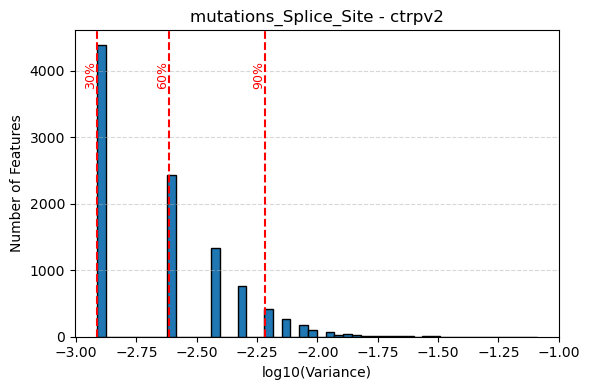

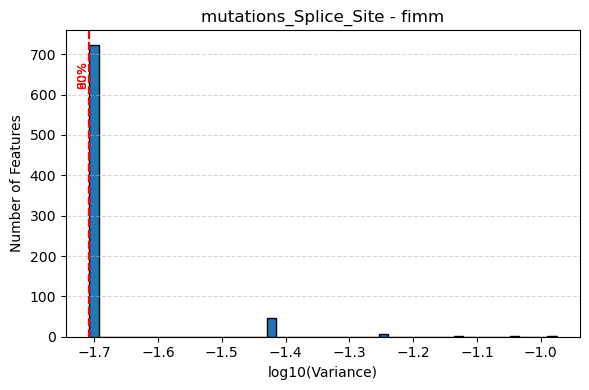

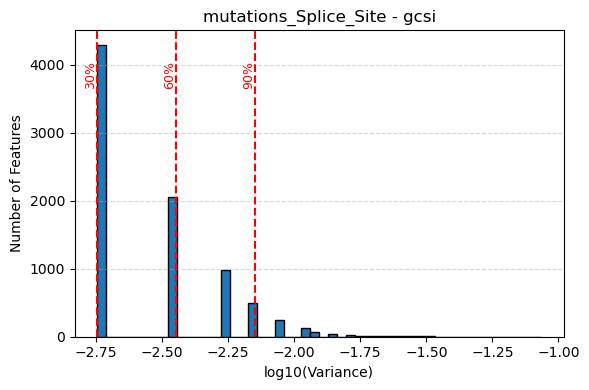

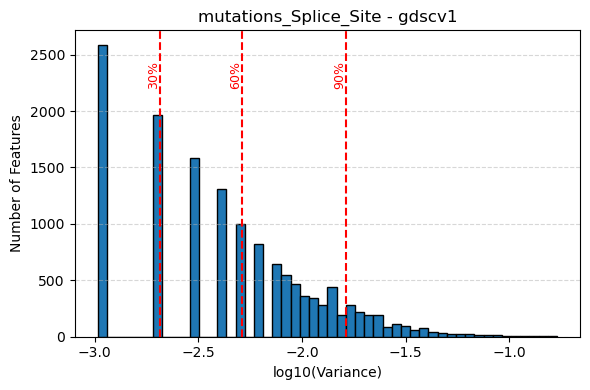

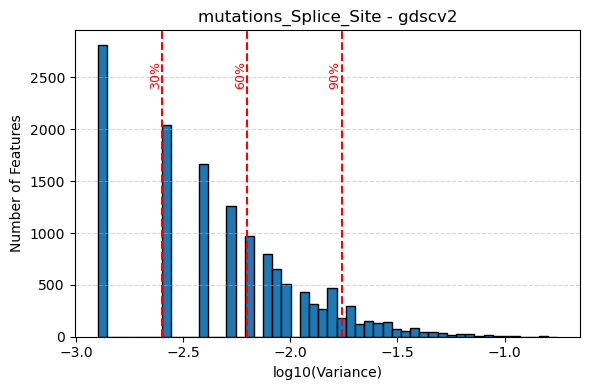

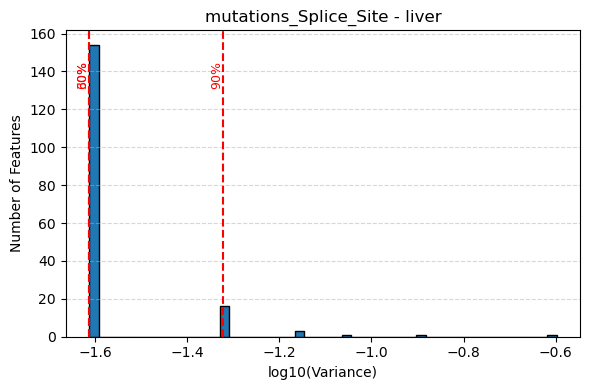

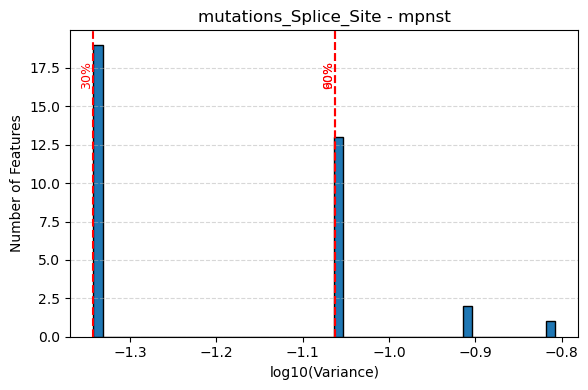

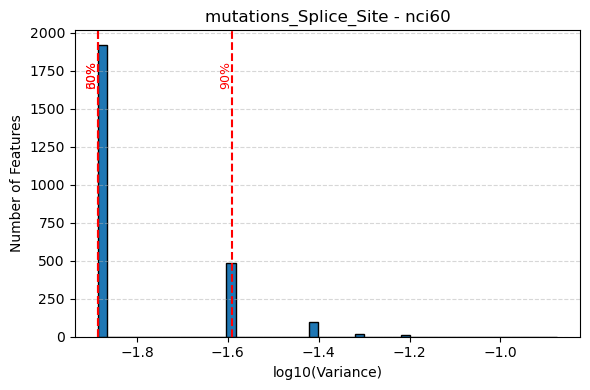

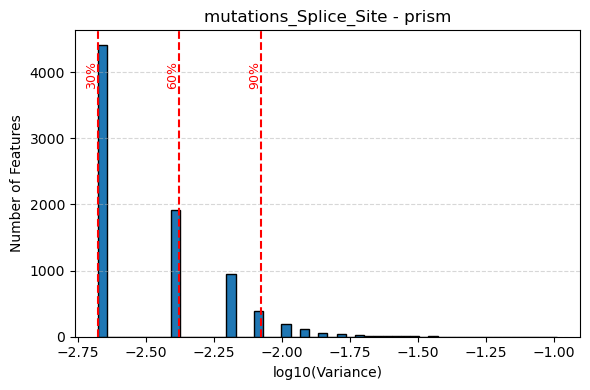

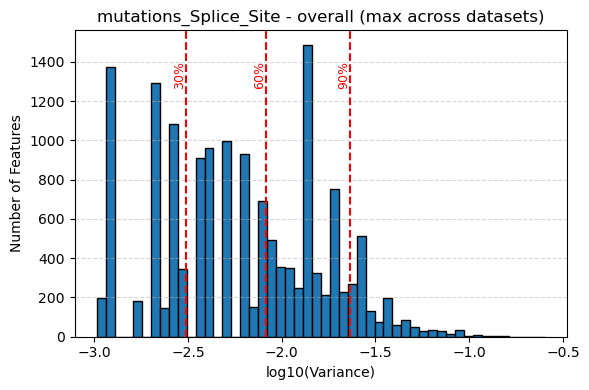

📊 Plotting variance distribution for feature group: mutations_3'Flank
   ⚠️ Skipping mutations_3'Flank - ccle: no positive variances to plot
   ⚠️ Skipping mutations_3'Flank - ctrpv2: no positive variances to plot
   ⚠️ Skipping mutations_3'Flank - fimm: no positive variances to plot
   ⚠️ Skipping mutations_3'Flank - gcsi: no positive variances to plot
   ⚠️ Skipping mutations_3'Flank - gdscv1: no positive variances to plot
   ⚠️ Skipping mutations_3'Flank - gdscv2: no positive variances to plot
   ⚠️ Skipping mutations_3'Flank - liver: no positive variances to plot


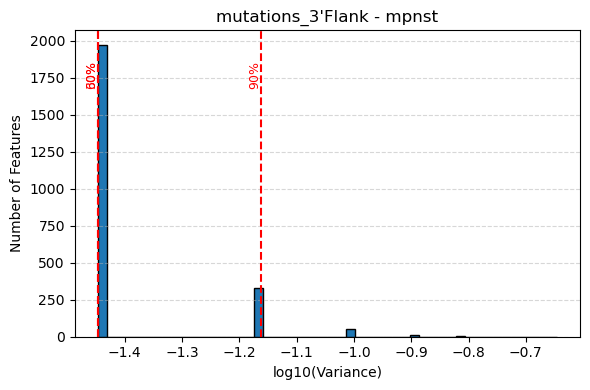

   ⚠️ Skipping mutations_3'Flank - nci60: no positive variances to plot
   ⚠️ Skipping mutations_3'Flank - prism: no positive variances to plot


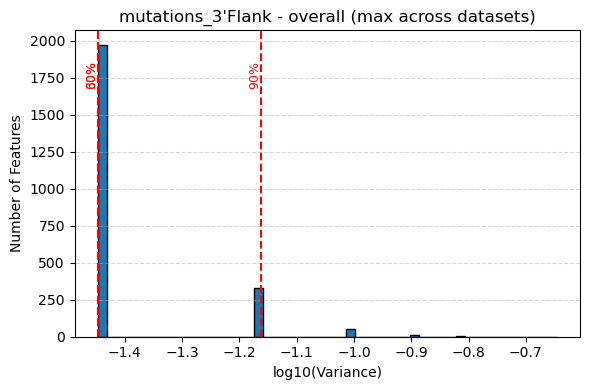

📊 Plotting variance distribution for feature group: mutations_Stop_Codon_Del
   ⚠️ Skipping mutations_Stop_Codon_Del - ccle: no positive variances to plot
   ⚠️ Skipping mutations_Stop_Codon_Del - ctrpv2: no positive variances to plot
   ⚠️ Skipping mutations_Stop_Codon_Del - fimm: no positive variances to plot
   ⚠️ Skipping mutations_Stop_Codon_Del - gcsi: no positive variances to plot


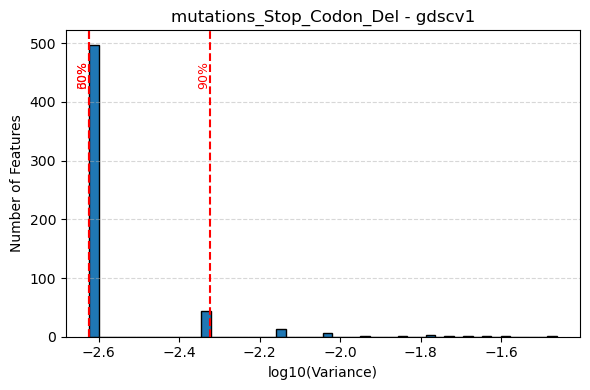

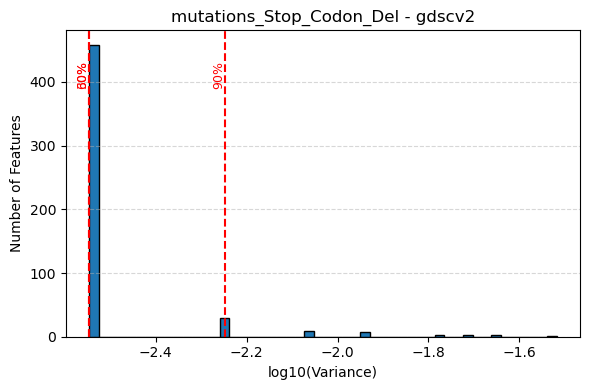

   ⚠️ Skipping mutations_Stop_Codon_Del - liver: no positive variances to plot
   ⚠️ Skipping mutations_Stop_Codon_Del - mpnst: no positive variances to plot
   ⚠️ Skipping mutations_Stop_Codon_Del - nci60: no positive variances to plot
   ⚠️ Skipping mutations_Stop_Codon_Del - prism: no positive variances to plot


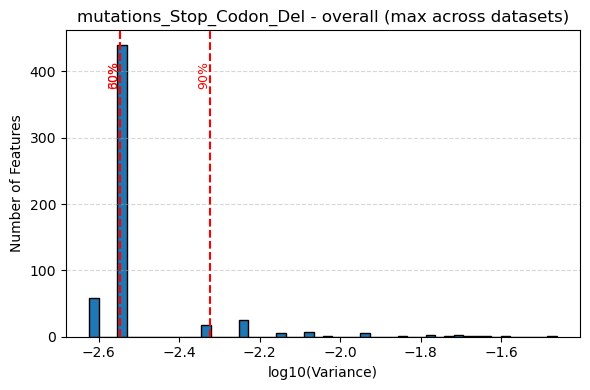

📊 Plotting variance distribution for feature group: mutations_In_Frame_Del


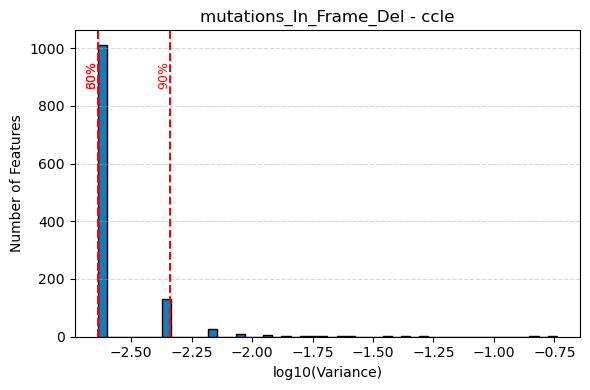

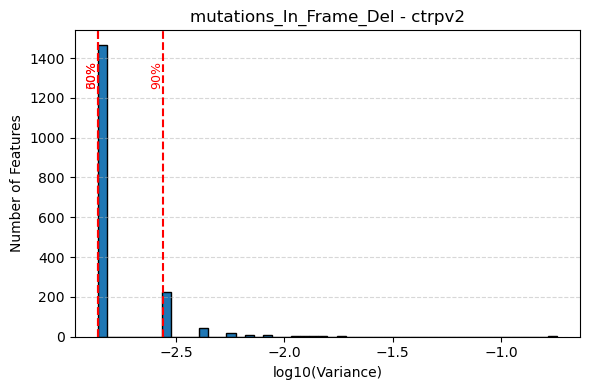

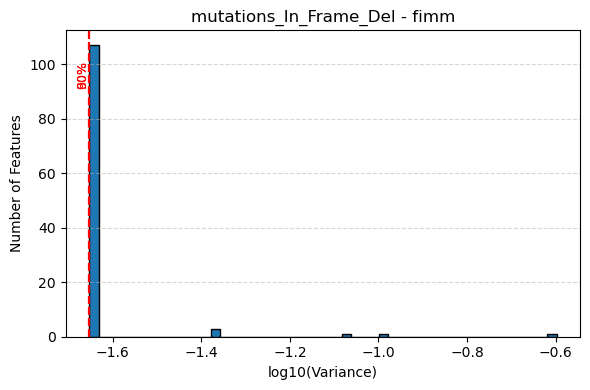

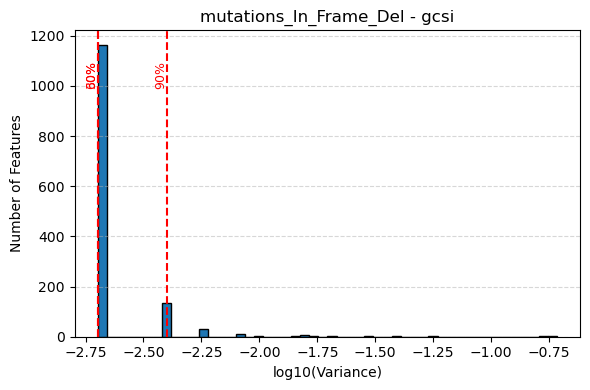

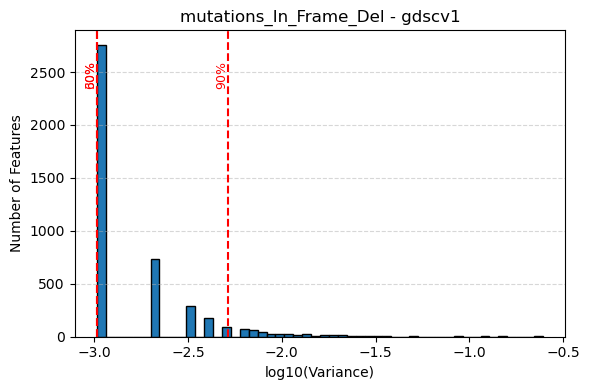

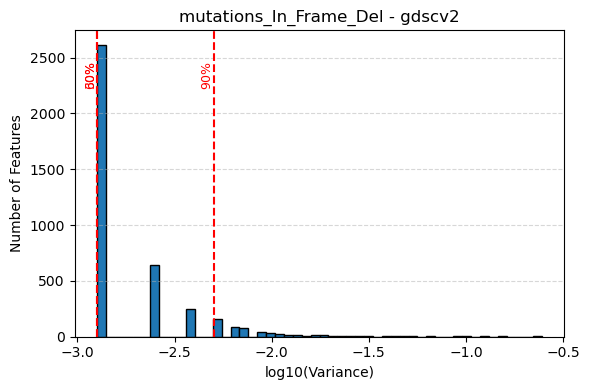

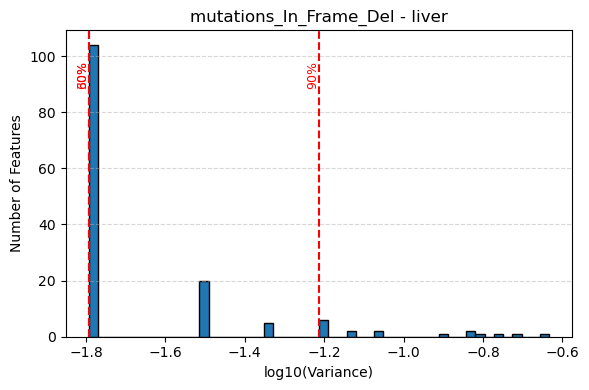

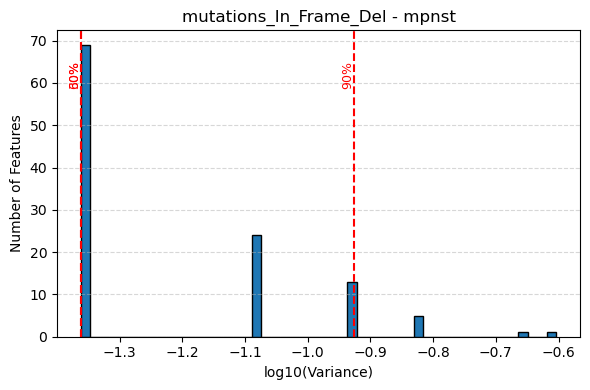

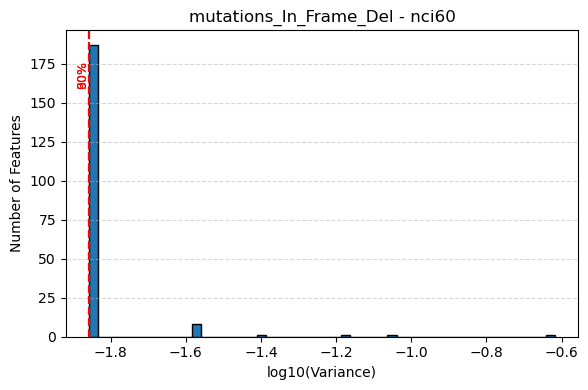

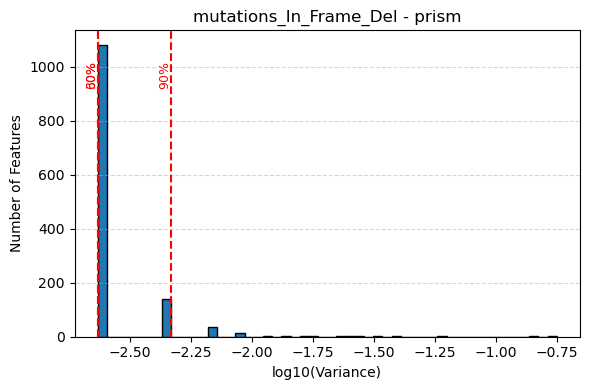

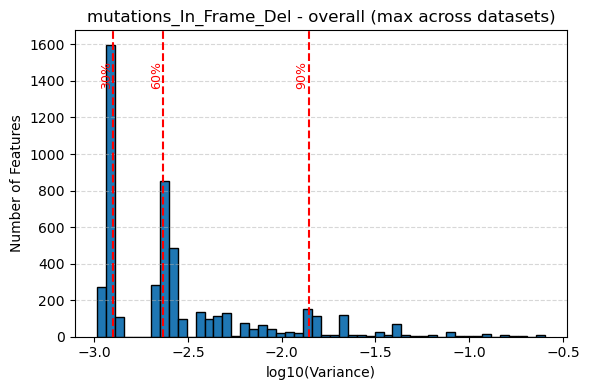

📊 Plotting variance distribution for feature group: mutations_Start_Codon_Del
   ⚠️ Skipping mutations_Start_Codon_Del - ccle: no positive variances to plot
   ⚠️ Skipping mutations_Start_Codon_Del - ctrpv2: no positive variances to plot
   ⚠️ Skipping mutations_Start_Codon_Del - fimm: no positive variances to plot
   ⚠️ Skipping mutations_Start_Codon_Del - gcsi: no positive variances to plot


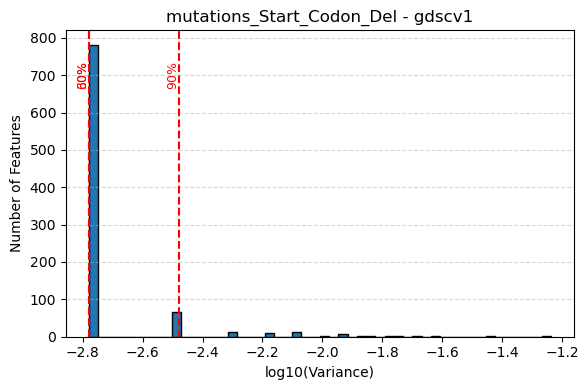

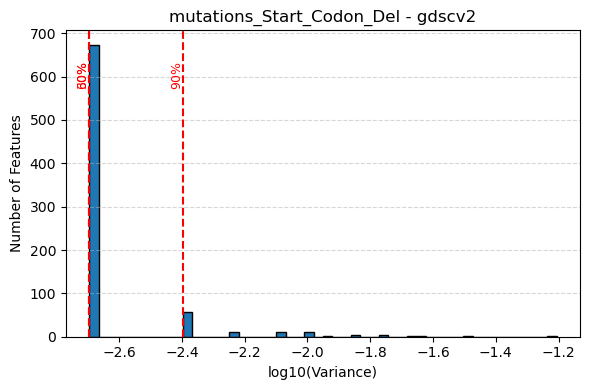

   ⚠️ Skipping mutations_Start_Codon_Del - liver: no positive variances to plot
   ⚠️ Skipping mutations_Start_Codon_Del - mpnst: no positive variances to plot
   ⚠️ Skipping mutations_Start_Codon_Del - nci60: no positive variances to plot
   ⚠️ Skipping mutations_Start_Codon_Del - prism: no positive variances to plot


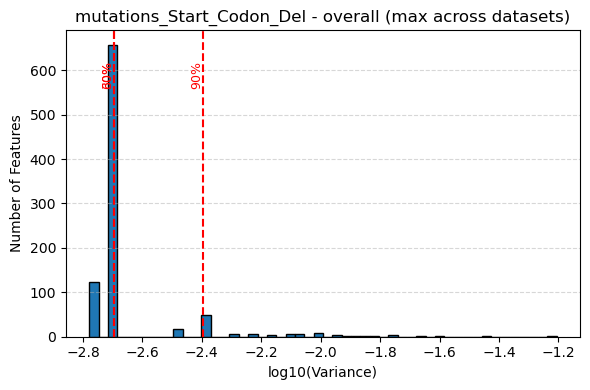

📊 Plotting variance distribution for feature group: mutations_Start_Codon_SNP


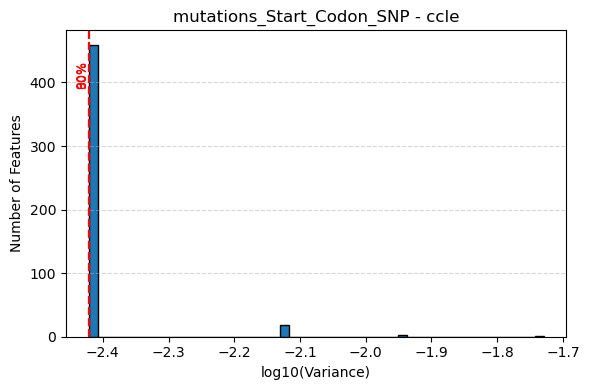

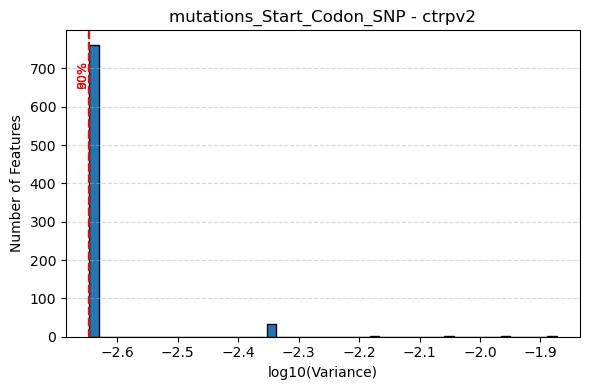

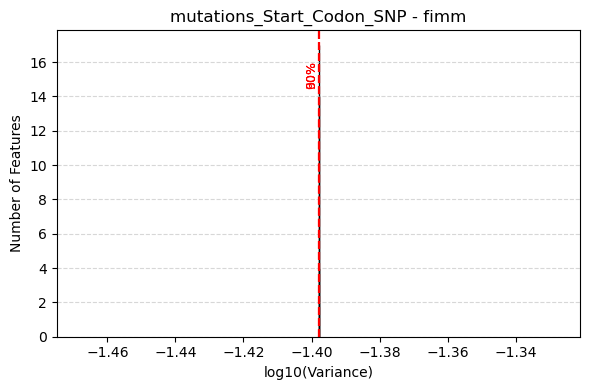

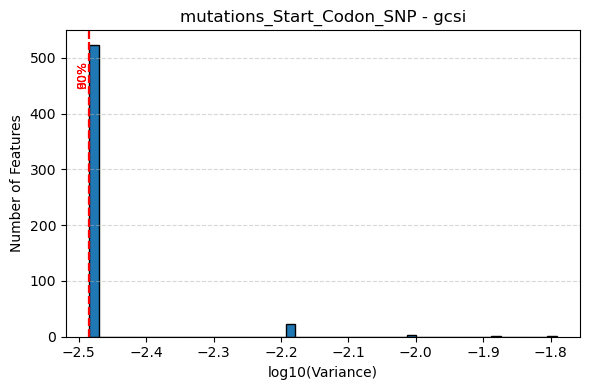

   ⚠️ Skipping mutations_Start_Codon_SNP - gdscv1: no positive variances to plot
   ⚠️ Skipping mutations_Start_Codon_SNP - gdscv2: no positive variances to plot
   ⚠️ Skipping mutations_Start_Codon_SNP - liver: no positive variances to plot
   ⚠️ Skipping mutations_Start_Codon_SNP - mpnst: no positive variances to plot


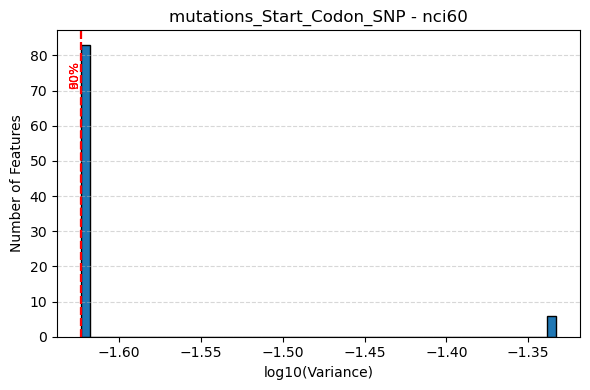

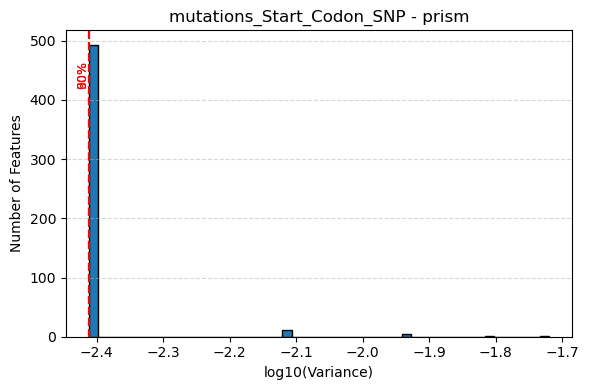

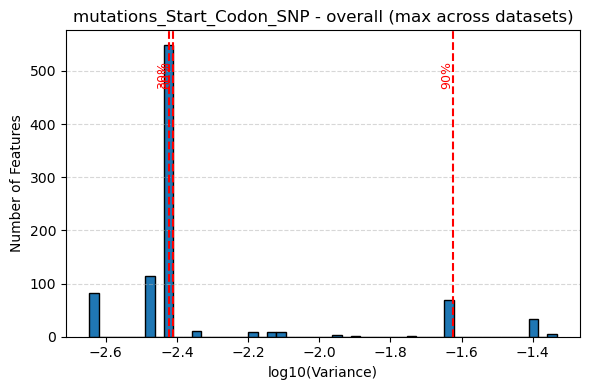

📊 Plotting variance distribution for feature group: mutations_Start_Codon_Ins


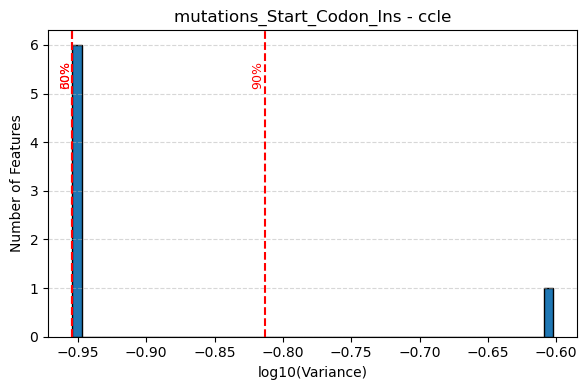

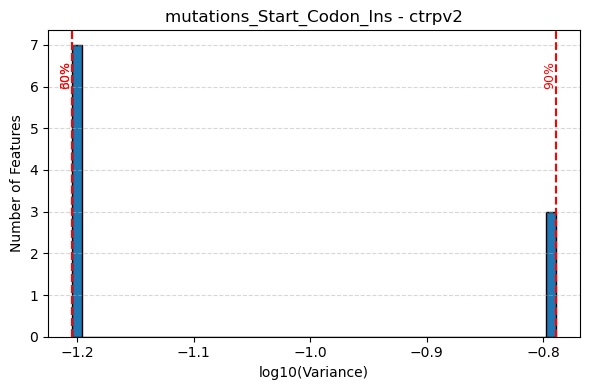

   ⚠️ Skipping mutations_Start_Codon_Ins - fimm: no positive variances to plot


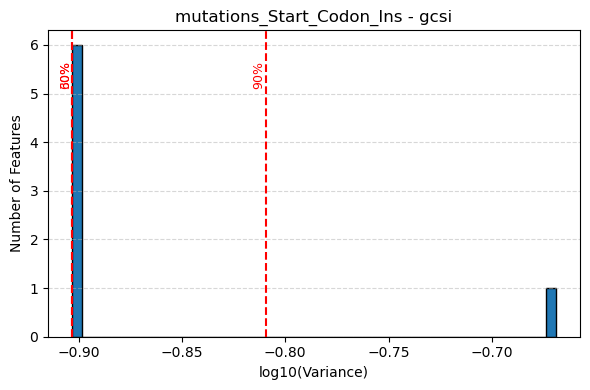

   ⚠️ Skipping mutations_Start_Codon_Ins - gdscv1: no positive variances to plot
   ⚠️ Skipping mutations_Start_Codon_Ins - gdscv2: no positive variances to plot
   ⚠️ Skipping mutations_Start_Codon_Ins - liver: no positive variances to plot
   ⚠️ Skipping mutations_Start_Codon_Ins - mpnst: no positive variances to plot
   ⚠️ Skipping mutations_Start_Codon_Ins - nci60: no positive variances to plot


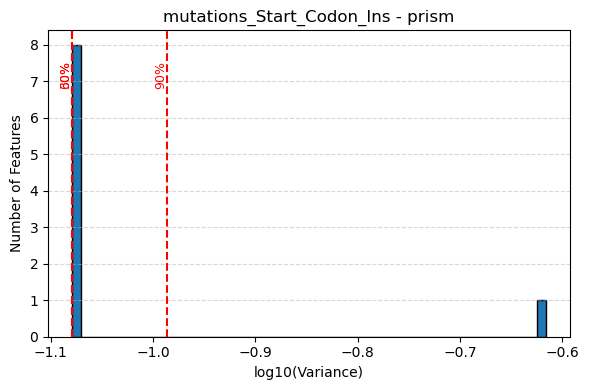

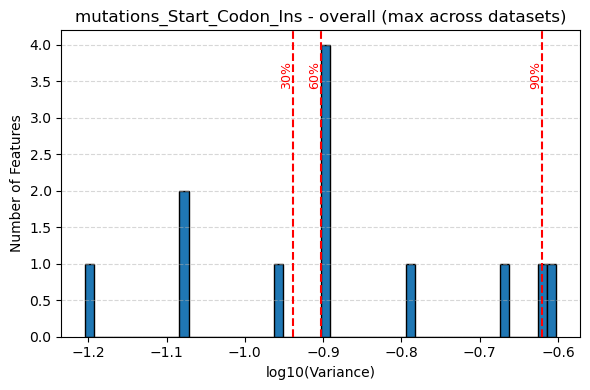

In [11]:
importlib.reload(coderdata_processing)
from coderdata_processing import plot_feature_variance_distribution

plot_feature_variance_distribution(unified_datasets)

In [20]:
importlib.reload(coderdata_processing)
from coderdata_processing import count_features_by_variance_range

var_ranges = [(0, 0.01), (0.01, 0.1), (0.1, 1), (1, 10), (10, 100)]
var_summary = count_features_by_variance_range(unified_datasets, var_ranges)
for data, counts in var_summary.items():
    print(f"Dataset: {data}")
    for var_range, count in counts.items():
        print(f"  Variance Range {var_range}: {count} features")

Dataset: transcriptomics
  Variance Range ccle: {'below_min': 0, 'range_(0,0.01)': 1418, 'range_(0.01,0.1)': 1783, 'range_(0.1,1)': 13169, 'range_(1,10)': 2496, 'range_(10,100)': 0, 'above_max': 0} features
  Variance Range ctrpv2: {'below_min': 0, 'range_(0,0.01)': 1276, 'range_(0.01,0.1)': 1693, 'range_(0.1,1)': 13169, 'range_(1,10)': 2728, 'range_(10,100)': 0, 'above_max': 0} features
  Variance Range fimm: {'below_min': 0, 'range_(0,0.01)': 2087, 'range_(0.01,0.1)': 1825, 'range_(0.1,1)': 12408, 'range_(1,10)': 2546, 'range_(10,100)': 0, 'above_max': 0} features
  Variance Range gcsi: {'below_min': 0, 'range_(0,0.01)': 1344, 'range_(0.01,0.1)': 1728, 'range_(0.1,1)': 13221, 'range_(1,10)': 2573, 'range_(10,100)': 0, 'above_max': 0} features
  Variance Range gdscv1: {'below_min': 0, 'range_(0,0.01)': 931, 'range_(0.01,0.1)': 1501, 'range_(0.1,1)': 12849, 'range_(1,10)': 3733, 'range_(10,100)': 0, 'above_max': 0} features
  Variance Range gdscv2: {'below_min': 0, 'range_(0,0.01)': 92

In [15]:
# Filter out biomarkers with too few samples
feature_reduced_dfs = filter_biomarkers(unified_datasets, data_size_ref, proportion=1e-2)

Feature mutations_Start_Codon_Del is filtered out due to insufficient samples
Feature mutations_Translation_Start_Site is filtered out due to insufficient samples
Feature mutations_3'Flank is filtered out due to insufficient samples
Feature mutations_Intron is filtered out due to insufficient samples
Feature mutations_Stop_Codon_Del is filtered out due to insufficient samples
Feature mutations_3'UTR is filtered out due to insufficient samples
Feature mutations_5'Flank is filtered out due to insufficient samples
Feature mutations_Splice_Region is filtered out due to insufficient samples
Feature mutations_5'UTR is filtered out due to insufficient samples


In [16]:
feature_reduced_dfs = unify_cell_ids_across_dfs(feature_reduced_dfs)
dim_reduced_dfs = filter_feature(feature_reduced_dfs)


relative_log_vars for transcriptomics: -1.2512700930786007, user defined log_thres: -1.0
Feature transcriptomics: selected 17783 out of 19425 features
relative_log_vars for proteomics: 1.0535335379132849, user defined log_thres: -1.0
Feature proteomics: selected 12899 out of 12960 features
relative_log_vars for copy_number: -1.546325933894539, user defined log_thres: -1.0
Feature copy_number: selected 27272 out of 27287 features
relative_log_vars for mutations_Missense_Mutation: -2.731458061789337, user defined log_thres: -1.0
Feature mutations_Missense_Mutation: selected 1363 out of 18915 features
relative_log_vars for mutations_Nonsense_Mutation: -3.75202664616602, user defined log_thres: -1.0
Feature mutations_Nonsense_Mutation: selected 8 out of 13426 features
relative_log_vars for mutations_Splice_Site: -3.5163142963500724, user defined log_thres: -1.0
Feature mutations_Splice_Site: selected 21 out of 15247 features
relative_log_vars for mutations_Frame_Shift_Ins: -3.9795069449866

In [17]:
# Normalization
dim_reduced_dfs["transcriptomics"] = binarize_across_dfs(dim_reduced_dfs["transcriptomics"], "transcriptomics")
if include_proteomics:
    dim_reduced_dfs["proteomics"] = binarize_across_dfs(dim_reduced_dfs["proteomics"], "proteomics")
if include_copy_number:
    dim_reduced_dfs["copy_number"] = binarize_across_dfs(dim_reduced_dfs["copy_number"], "copy_number")

Binarizing transcriptomics data for ccle with shape (494, 17783)
Binarizing transcriptomics data for ctrpv2 with shape (837, 17783)
Binarizing transcriptomics data for fimm with shape (51, 17783)
Binarizing transcriptomics data for gcsi with shape (564, 17783)
Binarizing transcriptomics data for gdscv1 with shape (980, 17783)
Binarizing transcriptomics data for gdscv2 with shape (804, 17783)
Binarizing transcriptomics data for liver with shape (62, 17783)
Binarizing transcriptomics data for mpnst with shape (33, 17783)
Binarizing transcriptomics data for nci60 with shape (79, 17783)
Binarizing transcriptomics data for prism with shape (477, 17783)
Binarizing proteomics data for ccle with shape (494, 12899)
Binarizing proteomics data for ctrpv2 with shape (837, 12899)
Binarizing proteomics data for fimm with shape (51, 12899)
Binarizing proteomics data for gcsi with shape (564, 12899)
Binarizing proteomics data for gdscv1 with shape (980, 12899)
Binarizing proteomics data for gdscv2 wit

In [20]:
importlib.reload(coderdata_processing)
from coderdata_processing import create_binary_cell_dfs

binary_cell_dfs, _ = create_binary_cell_dfs(dim_reduced_dfs)
for name, df in binary_cell_dfs.items():
    print(f"Binary cell df for {name}: shape {df.shape}")
    display(df.head())

Dataset ccle, Feature transcriptomics: shape (494, 106698)
Dataset ctrpv2, Feature transcriptomics: shape (837, 106698)
Dataset fimm, Feature transcriptomics: shape (51, 106698)
Dataset gcsi, Feature transcriptomics: shape (564, 106698)
Dataset gdscv1, Feature transcriptomics: shape (980, 106698)
Dataset gdscv2, Feature transcriptomics: shape (804, 106698)
Dataset liver, Feature transcriptomics: shape (62, 106698)
Dataset mpnst, Feature transcriptomics: shape (33, 106698)
Dataset nci60, Feature transcriptomics: shape (79, 106698)
Dataset prism, Feature transcriptomics: shape (477, 106698)
Dataset ccle, Feature proteomics: shape (494, 77394)
Dataset ctrpv2, Feature proteomics: shape (837, 77394)
Dataset fimm, Feature proteomics: shape (51, 77394)
Dataset gcsi, Feature proteomics: shape (564, 77394)
Dataset gdscv1, Feature proteomics: shape (980, 77394)
Dataset gdscv2, Feature proteomics: shape (804, 77394)
Dataset liver, Feature proteomics: shape (62, 77394)
Dataset mpnst, Feature prote

,improve_sample_id,transcriptomics,proteomics,copy_number,mutations_Missense_Mutation,mutations_Nonsense_Mutation,mutations_Splice_Site,mutations_Frame_Shift_Ins,mutations_In_Frame_Ins,mutations_Silent,mutations_Frame_Shift_Del,mutations_In_Frame_Del
1,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,4,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
9,9,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
10,10,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
12,12,"[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


Binary cell df for ctrpv2: shape (837, 12)


,improve_sample_id,transcriptomics,proteomics,copy_number,mutations_Missense_Mutation,mutations_Nonsense_Mutation,mutations_Splice_Site,mutations_Frame_Shift_Ins,mutations_In_Frame_Ins,mutations_Silent,mutations_Frame_Shift_Del,mutations_In_Frame_Del
1,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,2,"[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,3,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6,6,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
7,7,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


Binary cell df for fimm: shape (51, 12)


...

,improve_sample_id,transcriptomics,proteomics,copy_number,mutations_Missense_Mutation,mutations_Nonsense_Mutation,mutations_Splice_Site,mutations_Frame_Shift_Ins,mutations_In_Frame_Ins,mutations_Silent,mutations_Frame_Shift_Del,mutations_In_Frame_Del
3841,3841,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3842,3842,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3843,3843,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
3844,3844,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3845,3845,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


Binary cell df for nci60: shape (79, 12)


,improve_sample_id,transcriptomics,proteomics,copy_number,mutations_Missense_Mutation,mutations_Nonsense_Mutation,mutations_Splice_Site,mutations_Frame_Shift_Ins,mutations_In_Frame_Ins,mutations_Silent,mutations_Frame_Shift_Del,mutations_In_Frame_Del
521,521,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
37,37,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
46,46,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
60,60,"[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
590,590,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


Binary cell df for prism: shape (477, 12)


,improve_sample_id,transcriptomics,proteomics,copy_number,mutations_Missense_Mutation,mutations_Nonsense_Mutation,mutations_Splice_Site,mutations_Frame_Shift_Ins,mutations_In_Frame_Ins,mutations_Silent,mutations_Frame_Shift_Del,mutations_In_Frame_Del
1,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,3,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,4,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6,6,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
9,9,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [ ]:
cell_features = cat_cell_features_across_datasets(binary_cell_dfs)


In [30]:
X = cell_features
from sklearn.feature_selection import VarianceThreshold
X_reduced = VarianceThreshold(threshold=0.01).fit_transform(X)
print(X_reduced.shape)



(4381, 145492)


(4381, 458612)


/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/tmp/ipykernel_20241/3483797328.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], cmap="Spectral", s=1, alpha=0.6)


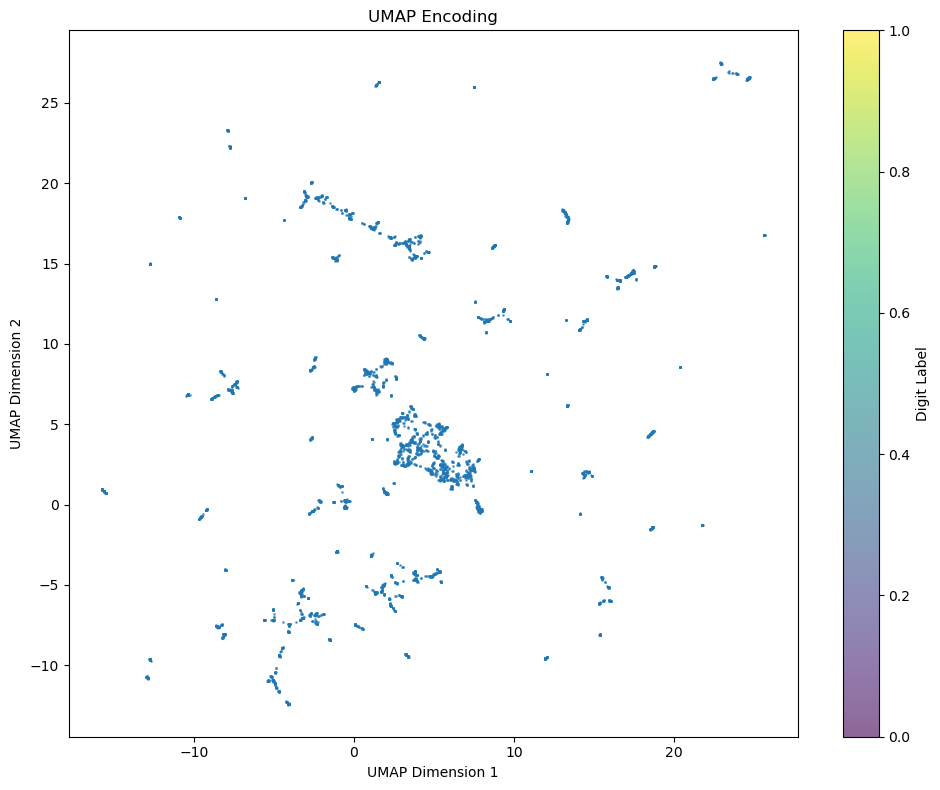

In [28]:
print(cell_features.shape)
umap = UMAP()
# umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
# Fit and transform the data
X_train_umap = umap.fit_transform(cell_features)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
drugs_ref_dfs = {}
for name, data in selected_datasets.items():
    drugs_ref_dfs[name] = data.drugs.drop_duplicates(subset=["improve_drug_id"], inplace=False)

metric = "fit_auc"
experiments_dfs = clean_experiments_across_dfs(selected_datasets, metric=metric)

/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column], errors='coerce')
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column], errors='coerce')


Dataset 'ccle': Cleaned 2780 rows with NaN or infinite 'dose_response_value' values.
Dataset 'ctrpv2': Cleaned 156304 rows with NaN or infinite 'dose_response_value' values.
Dataset 'fimm': Cleaned 693 rows with NaN or infinite 'dose_response_value' values.
Dataset 'gcsi': Cleaned 3495 rows with NaN or infinite 'dose_response_value' values.


/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column], errors='coerce')
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column], errors='coerce')
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

Dataset 'gdscv1': Cleaned 93396 rows with NaN or infinite 'dose_response_value' values.
Dataset 'gdscv2': Cleaned 45480 rows with NaN or infinite 'dose_response_value' values.
Dataset 'liver': Cleaned 669 rows with NaN or infinite 'dose_response_value' values.
Dataset 'mpnst': Cleaned 54 rows with NaN or infinite 'dose_response_value' values.


/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column], errors='coerce')
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column], errors='coerce')
/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

Dataset 'nci60': Cleaned 1831668 rows with NaN or infinite 'dose_response_value' values.


/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column], errors='coerce')


Dataset 'prism': Cleaned 129445 rows with NaN or infinite 'dose_response_value' values.


In [ ]:
experiments_dfs_sampled = dip_experiments_across_dfs(experiments_dfs, fraction=0.01)

In [ ]:
experiments_dfs_sampled

{'ccle':            source  improve_sample_id improve_drug_id study  time time_unit  \
 1576   pharmacoGX                266       SMI_36112  CCLE    72     hours   
 10420  pharmacoGX               1778       SMI_23457  CCLE    72     hours   
 2028   pharmacoGX                347       SMI_31997  CCLE    72     hours   
 4790   pharmacoGX                690       SMI_44331  CCLE    72     hours   
 9960   pharmacoGX               1652       SMI_36067  CCLE    72     hours   
 ...           ...                ...             ...   ...   ...       ...   
 1289   pharmacoGX                177       SMI_48746  CCLE    72     hours   
 6174   pharmacoGX                849       SMI_41675  CCLE    72     hours   
 9390   pharmacoGX               1461       SMI_37951  CCLE    72     hours   
 466    pharmacoGX                 63       SMI_57322  CCLE    72     hours   
 1235   pharmacoGX                172       SMI_36112  CCLE    72     hours   
 
       dose_response_metric  dose_response

📊 Summary statistics:

count    20499.000000
mean         0.762644
std          0.126471
min          0.000000
5%           0.503990
25%          0.715400
50%          0.796200
75%          0.852600
95%          0.891500
max          0.900000



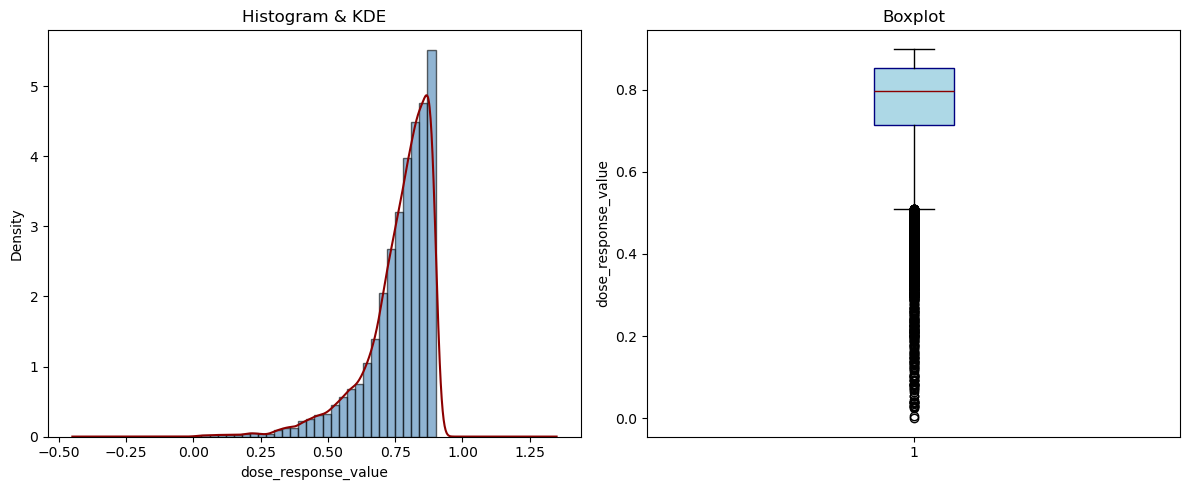

In [ ]:
visualize_sample_response_statistics(experiments_dfs_sampled)

In [ ]:
feature_dict_footprint, resp_footprint = preprocess_experiment_with_footprint(experiments_dfs_sampled, drugs_ref_dfs, dim_reduced_dfs, drug_target=None, show_status=True)

Processing dataset: ccle with 88 experiments
Finished processing dataset: ccle with 88 selected samples
Processing dataset: ctrpv2 with 1531 experiments
Finished processing dataset: ctrpv2 with 1531 selected samples
Processing dataset: fimm with 20 experiments
Finished processing dataset: fimm with 20 selected samples
Processing dataset: gcsi with 99 experiments
Finished processing dataset: gcsi with 99 selected samples
Processing dataset: gdscv1 with 1544 experiments
Finished processing dataset: gdscv1 with 1544 selected samples
Processing dataset: gdscv2 with 700 experiments
Finished processing dataset: gdscv2 with 700 selected samples
Processing dataset: liver with 38 experiments
Finished processing dataset: liver with 38 selected samples
Processing dataset: mpnst with 2 experiments
Finished processing dataset: mpnst with 2 selected samples
Processing dataset: nci60 with 11382 experiments


[07:51:44] Explicit valence for atom # 0 Cl, 1, is greater than permitted


Invalid SMILES for drug ID SMI_55935
Skipping experiment 154065 with drug ID SMI_55935 due to invalid SMILES
Finished processing dataset: nci60 with 11381 selected samples
Processing dataset: prism with 5095 experiments
Finished processing dataset: prism with 5095 selected samples


In [ ]:
# X, y = cat_drug_response_features_across_datasets(feature_dict_footprint, resp_footprint, unique_cell_ids_across_dfs, ["transcriptomics", "proteomics", "copy_number"])
X, y = cat_drug_response_features_across_datasets(feature_dict_footprint, resp_footprint, unique_cell_ids_across_dfs, ["transcriptomics", "proteomics", "copy_number"])

In [ ]:
print(X.shape)

is_binary = np.all((X == 0) | (X == 1))

print(is_binary)  # True if all 0 or 1, False otherwise

(11512, 303238)
True


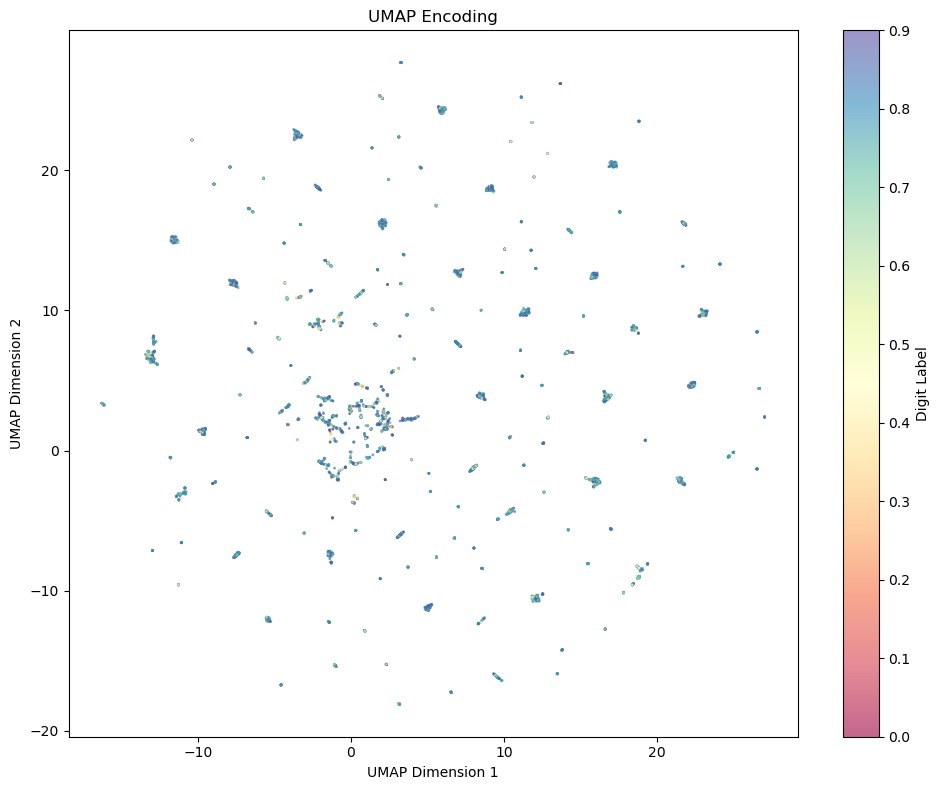

In [ ]:
umap = UMAP()
# umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
# Fit and transform the data
X_train_umap = umap.fit_transform(X)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y, cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
save_dfs_as_pt(
    experiments_dfs_sampled,
    drugs_ref_dfs,
    dim_reduced_dfs,
    unique_cell_ids_across_dfs,
    features=["transcriptomics", "copy_number"],
    n_chunks=4,
    save_dir=f"../data/pt_data/"
)

Saving ['transcriptomics', 'copy_number'] chunks:   0%|          | 0/4 [00:00<?, ?it/s]Process ForkProcess-6:
